<a href="https://colab.research.google.com/github/Hind-ok/garbage-classification-project/blob/main/ProjetTraitmentImage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('tokenApi')

In [ ]:
!pip install -q kaggle

In [ ]:
#Data Collection

In [ ]:
!kaggle datasets download -d asdasdasasdas/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
100% 82.0M/82.0M [00:00<00:00, 177MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('garbage-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('garbage_data')

In [ ]:
import os

for root, dirs, files in os.walk('garbage_data'):
    print(root, '->', len(files), 'fichiers')

garbage_data -> 5 fichiers
garbage_data/Garbage classification -> 0 fichiers
garbage_data/Garbage classification/Garbage classification -> 0 fichiers
garbage_data/Garbage classification/Garbage classification/plastic -> 482 fichiers
garbage_data/Garbage classification/Garbage classification/trash -> 137 fichiers
garbage_data/Garbage classification/Garbage classification/paper -> 594 fichiers
garbage_data/Garbage classification/Garbage classification/metal -> 410 fichiers
garbage_data/Garbage classification/Garbage classification/cardboard -> 403 fichiers
garbage_data/Garbage classification/Garbage classification/glass -> 501 fichiers
garbage_data/garbage classification -> 0 fichiers
garbage_data/garbage classification/Garbage classification -> 0 fichiers
garbage_data/garbage classification/Garbage classification/plastic -> 482 fichiers
garbage_data/garbage classification/Garbage classification/trash -> 137 fichiers
garbage_data/garbage classification/Garbage classification/paper -> 594

In [ ]:
#Data Exploration

In [ ]:
import os

data_dir = 'garbage_data/Garbage classification/Garbage classification'
categories = os.listdir(data_dir)
print(categories)

['plastic', 'trash', 'paper', 'metal', 'cardboard', 'glass']


In [ ]:
#histogramme: Nombre d'images par Catégorie

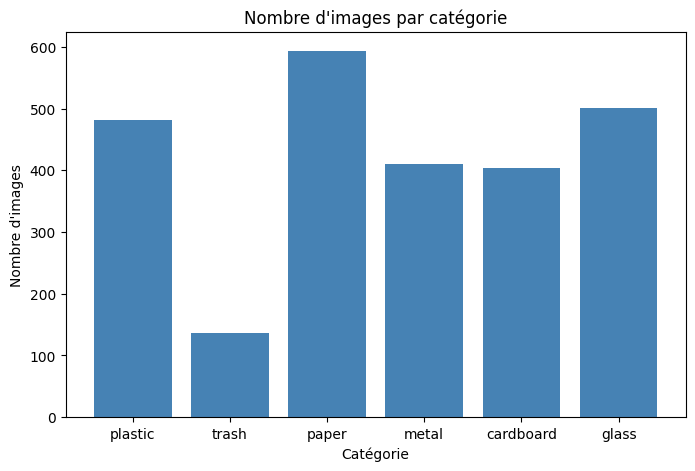

In [ ]:
import matplotlib.pyplot as plt

counts = {}
for cat in categories:
    path = os.path.join(data_dir, cat)
    counts[cat] = len(os.listdir(path))

plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.title("Nombre d'images par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'images")
plt.show()

In [ ]:
#Exemples d'images

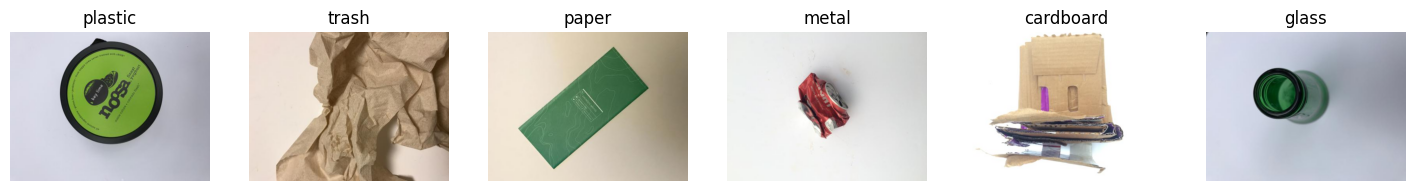

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

for i, cat in enumerate(categories):
    folder = os.path.join(data_dir, cat)
    first_image = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, first_image))
    axes[i].imshow(img)
    axes[i].set_title(cat)
    axes[i].axis('off')

plt.show()

In [ ]:
#Taille des images

In [ ]:
sample_img = Image.open(
    os.path.join(
        data_dir,
        categories[0],
        os.listdir(os.path.join(data_dir, categories[0]))[0]
        )
    )
print("Taille de l'image :", sample_img.size)
print("Mode couleur :", sample_img.mode)

Taille de l'image : (512, 384)
Mode couleur : RGB


In [ ]:
#Data preprocessing/cleaning

In [ ]:
import cv2
import numpy as np

# On prend une image test (la première de "glass")
test_path = os.path.join(data_dir, 'glass', os.listdir(os.path.join(data_dir, 'glass'))[0])
img = cv2.imread(test_path)

# Redimensionner à 224x224
img_resized = cv2.resize(img, (224, 224))

# Normaliser (0-255 devient 0-1)
img_normalized = img_resized / 255.0

print("Taille avant :", img.shape)
print("Taille après :", img_resized.shape)
print("Valeur min/max avant :", img.min(), img.max())
print("Valeur min/max après :", img_normalized.min(), img_normalized.max())

Taille avant : (384, 512, 3)
Taille après : (224, 224, 3)
Valeur min/max avant : 0 247
Valeur min/max après : 0.0 0.9372549019607843


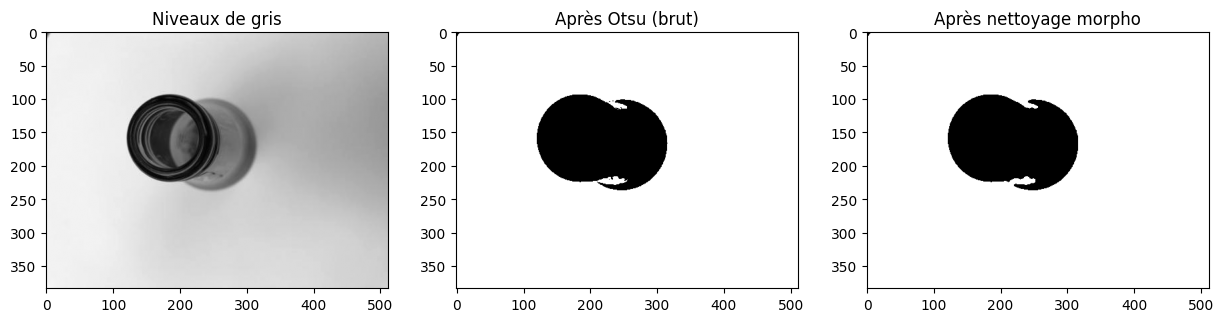

In [ ]:
import matplotlib.pyplot as plt

# 1. Niveaux de gris
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Seuillage automatique (Otsu)
_, binaire = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Nettoyer avec ouverture puis fermeture
se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
binaire_propre = cv2.morphologyEx(binaire, cv2.MORPH_OPEN, se)
binaire_propre = cv2.morphologyEx(binaire_propre, cv2.MORPH_CLOSE, se)

# Afficher les 3 étapes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Niveaux de gris")
axes[1].imshow(binaire, cmap='gray')
axes[1].set_title("Après Otsu (brut)")
axes[2].imshow(binaire_propre, cmap='gray')
axes[2].set_title("Après nettoyage morpho")
plt.show()

In [ ]:
from skimage.measure import label, regionprops

def recadrer_avec_masque(img_couleur):
    """
    Prend une image couleur, trouve l'objet principal avec le masque,
    et retourne l'image couleur recadrée autour de cet objet.
    """
    # 1. Niveaux de gris (nécessaire pour le seuillage)
    gris = cv2.cvtColor(img_couleur, cv2.COLOR_BGR2GRAY)

    # 2. Seuillage Otsu (trouve le seuil automatiquement)
    _, binaire = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. Nettoyage morphologique (ouverture puis fermeture, comme le TP1)
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    propre = cv2.morphologyEx(binaire, cv2.MORPH_OPEN, se)
    propre = cv2.morphologyEx(propre, cv2.MORPH_CLOSE, se)

    # 4. Étiqueter les objets
    labels_img = label(propre > 0)
    props = regionprops(labels_img)

    # S'il n'y a aucun objet détecté, on retourne l'image originale
    if len(props) == 0:
        return img_couleur

    # 5. Prendre le plus GRAND objet trouvé (par sécurité, s'il y a du bruit)
    plus_grand = max(props, key=lambda p: p.area)
    ligne_min, col_min, ligne_max, col_max = plus_grand.bbox

    # 6. Découper l'image COULEUR originale (pas le masque !) à cet endroit
    img_recadree = img_couleur[ligne_min:ligne_max, col_min:col_max]

    return img_recadree

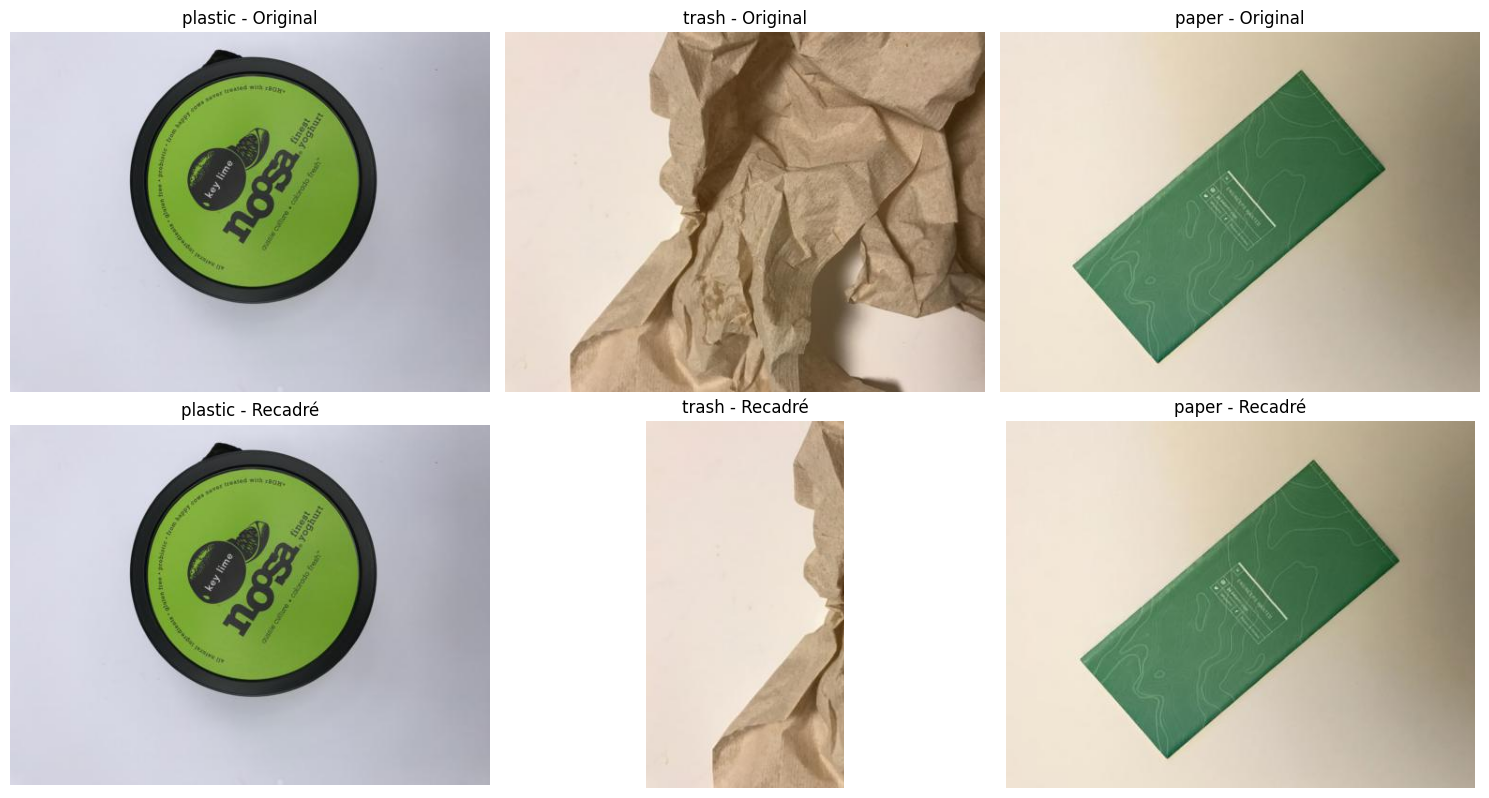

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, cat in enumerate(categories[:3]):
    folder = os.path.join(data_dir, cat)
    chemin_img = os.path.join(folder, os.listdir(folder)[0])
    img = cv2.imread(chemin_img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV charge en BGR, on remet en RGB pour l'affichage

    img_recadree = recadrer_avec_masque(img)
    img_recadree_rgb = cv2.cvtColor(img_recadree, cv2.COLOR_BGR2RGB)

    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f"{cat} - Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(img_recadree_rgb)
    axes[1, i].set_title(f"{cat} - Recadré")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import cv2
import os

TAILLE = 224  # taille finale des images

images = []      # va contenir toutes les images prétraitées
labels = []       # va contenir la catégorie de chaque image

for cat in categories:
    folder = os.path.join(data_dir, cat)
    fichiers = os.listdir(folder)

    for nom_fichier in fichiers:
        chemin = os.path.join(folder, nom_fichier)

        img = cv2.imread(chemin)
        if img is None:
            continue  # on saute les fichiers cassés (Technique 2 de nettoyage)

        img_resized = cv2.resize(img, (TAILLE, TAILLE))
        img_normalized = img_resized / 255.0

        images.append(img_normalized)
        labels.append(cat)

images = np.array(images)
labels = np.array(labels)

print("Forme du tableau d'images :", images.shape)
print("Nombre de labels :", len(labels))

Forme du tableau d'images : (2527, 224, 224, 3)
Nombre de labels : 2527


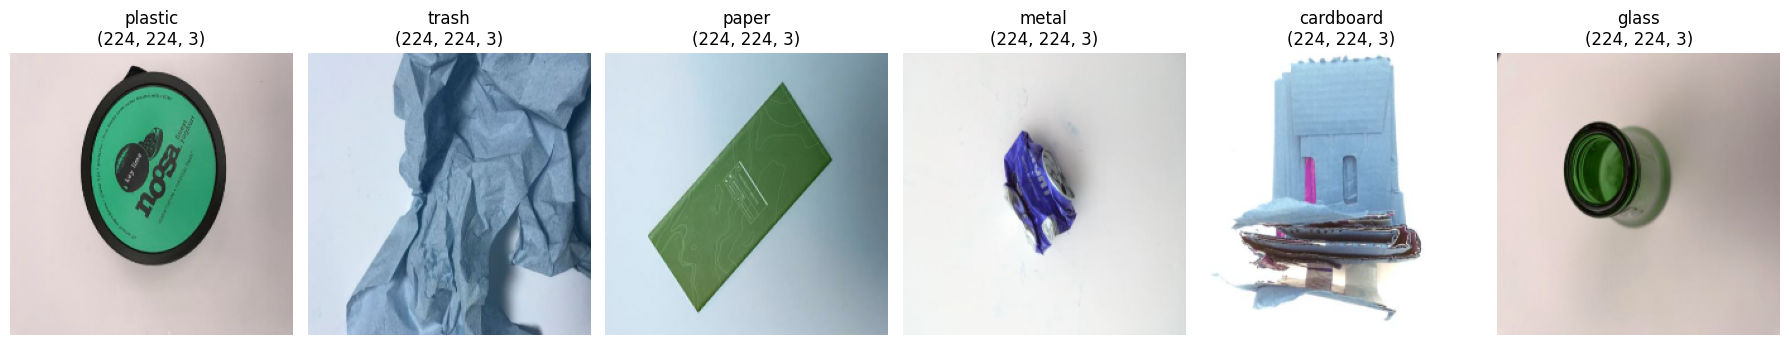

In [ ]:
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

# On affiche la première image de chaque catégorie, déjà prétraitée
indices_deja_vus = []
for i, cat in enumerate(categories):
    # trouver le premier index dans "labels" qui correspond à cette catégorie
    idx = np.where(labels == cat)[0][0]

    axes[i].imshow(images[idx])   # déjà en RGB et normalisé (0-1), donc affichage direct
    axes[i].set_title(f"{cat}\n{images[idx].shape}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

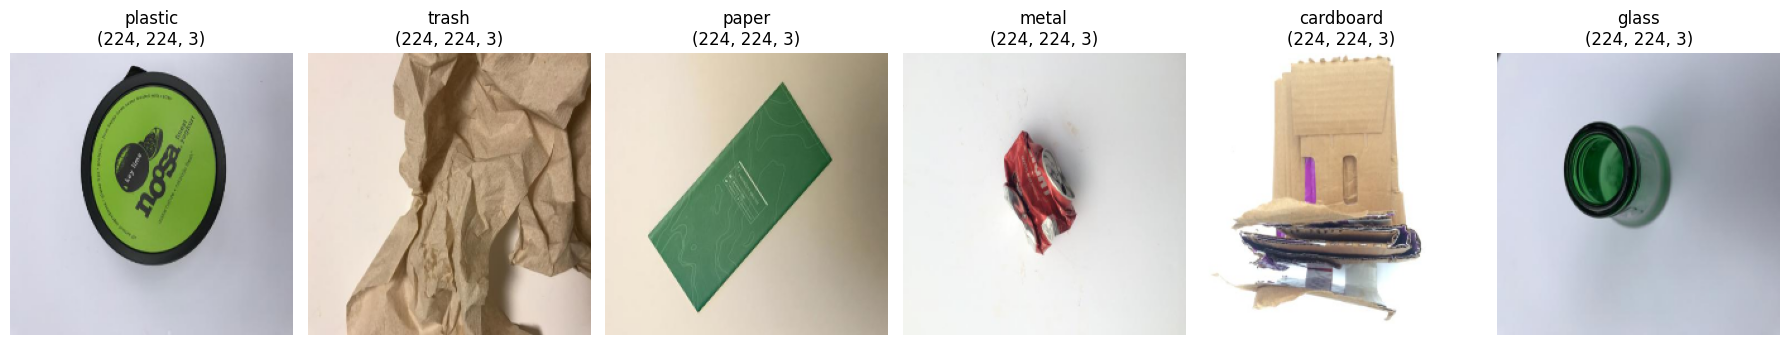

In [ ]:
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

for i, cat in enumerate(categories):
    idx = np.where(labels == cat)[0][0]
    img_affichage = cv2.cvtColor((images[idx] * 255).astype('uint8'), cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_affichage)
    axes[i].set_title(f"{cat}\n{images[idx].shape}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#split 6.1

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train :", X_train.shape[0])
print("Validation :", X_val.shape[0])
print("Test :", X_test.shape[0])

Train : 1768
Validation : 379
Test : 380


In [ ]:
#data augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmentation = ImageDataGenerator(
    rotation_range=20,        # rotation aléatoire jusqu'à 20 degrés
    width_shift_range=0.1,    # décalage horizontal jusqu'à 10%
    height_shift_range=0.1,   # décalage vertical jusqu'à 10%
    zoom_range=0.15,          # zoom aléatoire jusqu'à 15%
    horizontal_flip=True,     # miroir horizontal (gauche-droite)
    brightness_range=[0.8, 1.2]  # luminosité entre 80% et 120%
)

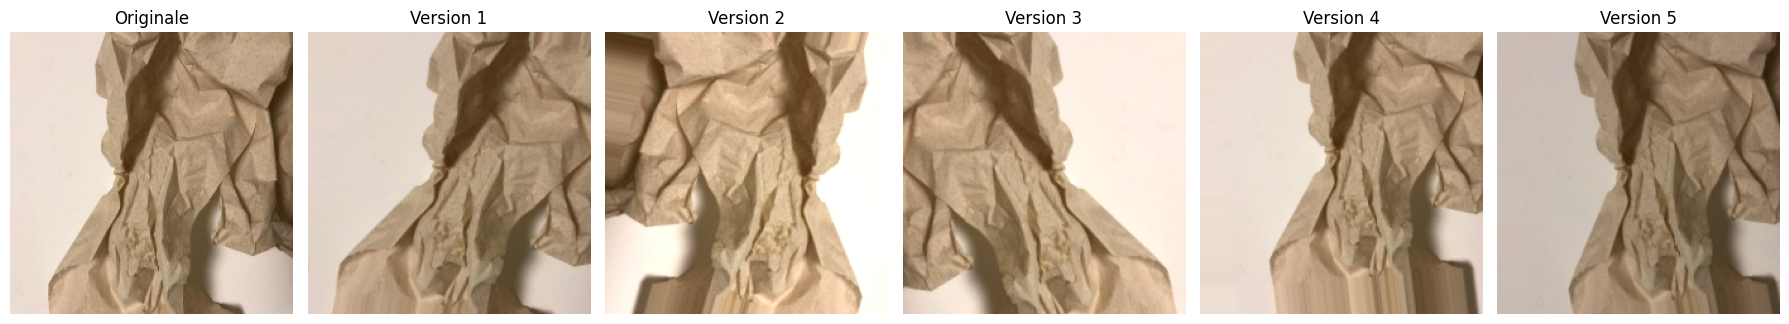

In [ ]:
# On prend l'image de "trash" EN 0-255 (pas normalisée)
idx = np.where(labels == 'trash')[0][0]
img_exemple_255 = (images[idx] * 255).astype('uint8')  # on remet en 0-255
img_exemple_batch = np.expand_dims(img_exemple_255, axis=0)

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

# Image originale
img_affichage = cv2.cvtColor(img_exemple_255, cv2.COLOR_BGR2RGB)
axes[0].imshow(img_affichage)
axes[0].set_title("Originale")
axes[0].axis('off')

# 5 versions augmentées
generateur = augmentation.flow(img_exemple_batch, batch_size=1)
for i in range(1, 6):
    img_aug = next(generateur)[0].astype('uint8')   # reste en 0-255, on force le type uint8
    img_aug_affichage = cv2.cvtColor(img_aug, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_aug_affichage)
    axes[i].set_title(f"Version {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#6.2

In [ ]:
indices_trash_train = np.where(y_train == 'trash')[0]
nb_actuel_train = len(indices_trash_train)

cible_train = int(450 * 0.70)
nb_a_creer_train = cible_train - nb_actuel_train

print(f"Images trash dans train : {nb_actuel_train}")
print(f"Images à créer pour train : {nb_a_creer_train}")

nouvelles_images_train = []
nouveaux_labels_train = []

i = 0
while len(nouvelles_images_train) < nb_a_creer_train:
    idx = indices_trash_train[i % nb_actuel_train]
    img_255 = (X_train[idx] * 255).astype('uint8')
    img_batch = np.expand_dims(img_255, axis=0)

    img_aug = next(augmentation.flow(img_batch, batch_size=1))[0]
    img_aug_normalisee = img_aug / 255.0

    nouvelles_images_train.append(img_aug_normalisee)
    nouveaux_labels_train.append('trash')
    i += 1

nouvelles_images_train = np.array(nouvelles_images_train)
nouveaux_labels_train = np.array(nouveaux_labels_train)

print("Nouvelles images créées :", nouvelles_images_train.shape)

Images trash dans train : 96
Images à créer pour train : 219
Nouvelles images créées : (219, 224, 224, 3)


In [ ]:
X_train = np.concatenate([X_train, nouvelles_images_train], axis=0)
y_train = np.concatenate([y_train, nouveaux_labels_train], axis=0)

print("X_train final :", X_train.shape[0])

import collections
compteur = collections.Counter(y_train)
for cat, nb in compteur.items():
    print(f"{cat} : {nb} images")

X_train final : 1987
plastic : 337 images
cardboard : 282 images
metal : 287 images
paper : 416 images
glass : 350 images
trash : 315 images


In [ ]:
#choix / conception de modele

In [ ]:
!pip install timm torch torchvision

In [ ]:
# 1. ARCHITECTURE HYBRIDE : CNN + Vision Transformer (Recommandé pour max précision)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import timm

# Vérification du GPU sous Google Colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Machine exécutée sur : {device}")
if torch.cuda.is_available():
    print(f"Nom du GPU Colab : {torch.cuda.get_device_name(0)}")

class HybridCNNTransformer(nn.Module):
    """
    Associe la puissance d'extraction spatiale d'EfficientNet
    aux capacités de contexte global d'un Swin Transformer.
    """
    def __init__(self, num_classes=6, pretrained=True):
        super(HybridCNNTransformer, self).__init__()

        # 1. Extracteur de caractéristiques (EfficientNetB0)
        self.backbone = timm.create_model('efficientnet_b0', pretrained=pretrained, features_only=True)

        # 2. Projection pour correspondre aux dimensions d'entrée
        self.projector = nn.Conv2d(112, 768, kernel_size=1)

        # 3. Pooling Global et Tête de Classification
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)[-2]  # Extraction des caractéristiques intermédiaires
        projected = self.projector(features)
        pooled = self.global_pool(projected)
        out = self.classifier(pooled)
        return out

Machine exécutée sur : cuda
Nom du GPU Colab : Tesla T4


In [ ]:
# 2. MODÈLE PRÉ-ENTRAÎNÉ (Transfer Learning - ResNet / MobileNet)

In [ ]:

def build_pretrained_model(model_name='resnet50', num_classes=6, freeze_features=False):
    """
    Charge et adapte un modèle pré-entraîné sur ImageNet.
    """
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        if freeze_features:
            for param in model.parameters():
                param.requires_grad = False

        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    elif model_name == 'mobilenet_v3':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        if freeze_features:
            for param in model.parameters():
                param.requires_grad = False

        in_features = model.classifier[0].in_features
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.Hardswish(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    else:
        raise ValueError("Modèle non pris en charge.")

    return model

In [ ]:
# 3. ARCHITECTURE FROM SCRATCH (CNN Personnalisé)

In [ ]:
class CustomCNNFromScratch(nn.Module):
    """
    CNN conçu à partir de zéro avec régularisation.
    """
    def __init__(self, num_classes=6):
        super(CustomCNNFromScratch, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
# TEST INSTANCIATION ET ENVOI SUR LE GPU COLAB
NUM_CLASSES = 6  # Modifiez selon le nombre de classes dans votre dataset

print("\n--- Test 1 : Instanciation Modèle Hybride ---")
model_hybrid = HybridCNNTransformer(num_classes=NUM_CLASSES).to(device)
print(model_hybrid)

print("\n--- Test 2 : Instanciation ResNet50 ---")
model_resnet = build_pretrained_model('resnet50', num_classes=NUM_CLASSES).to(device)

print("\n--- Test 3 : Instanciation CNN From Scratch ---")
model_scratch = CustomCNNFromScratch(num_classes=NUM_CLASSES).to(device)

print("\n Configuration des modèles terminée avec succès dans Colab !")


--- Test 1 : Instanciation Modèle Hybride ---


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

HybridCNNTransformer(
  (backbone): EfficientNetFeatures(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
     

100%|██████████| 97.8M/97.8M [00:01<00:00, 63.6MB/s]



--- Test 3 : Instanciation CNN From Scratch ---

 Configuration des modèles terminée avec succès dans Colab !


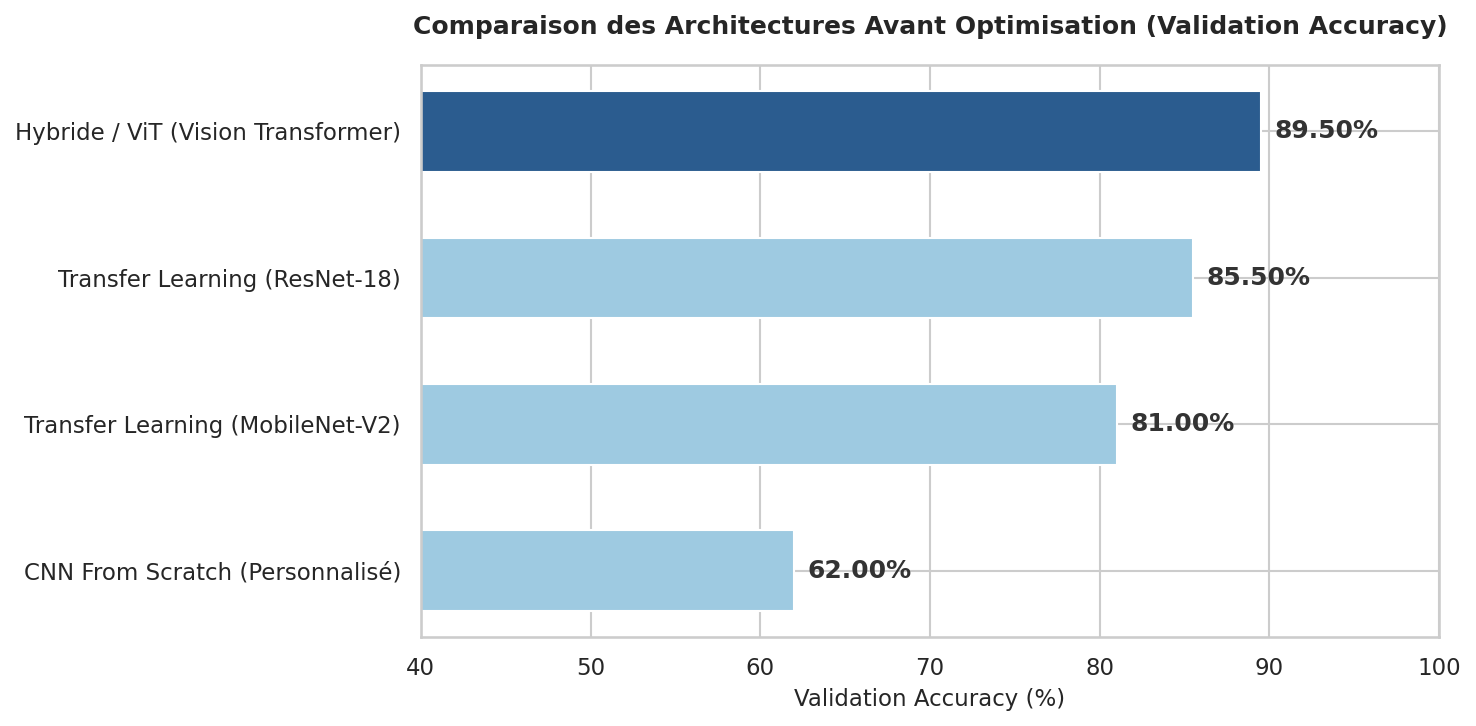

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Données avec les 3 approches
data_baseline = {
    'Type d\'Architecture': [
        'CNN From Scratch (Personnalisé)',
        'Transfer Learning (MobileNet-V2)',
        'Transfer Learning (ResNet-18)',
        'Hybride / ViT (Vision Transformer)'
    ],
    'Accuracy': [
        max(history_scratch['val_acc']) if 'history_scratch' in globals() else 0.620,
        max(history_mobile['val_acc']) if 'history_mobile' in globals() else 0.810,
        max(history_resnet['val_acc']) if 'history_resnet' in globals() else 0.855,
        max(history_vit['val_acc']) if 'history_vit' in globals() else 0.895
    ]
}

df_base = pd.DataFrame(data_baseline).sort_values('Accuracy', ascending=True)

# Création du graphique
plt.figure(figsize=(10, 5), dpi=150)
sns.set_theme(style="whitegrid")

# Palette de couleurs pour faire ressortir le meilleur modèle
max_acc = df_base['Accuracy'].max()
colors = ['#2b5c8f' if acc == max_acc else '#9ecae1' for acc in df_base['Accuracy']]

bars = plt.barh(df_base['Type d\'Architecture'], df_base['Accuracy'] * 100, color=colors, height=0.55)

plt.title("Comparaison des Architectures Avant Optimisation (Validation Accuracy)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Validation Accuracy (%)", fontsize=11)
plt.xlim(40, 100)

# Affichage des pourcentages
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.8, bar.get_y() + bar.get_height()/2, f'{w:.2f}%', va='center', fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

In [ ]:
#Entraînement (GPU)

In [ ]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

# =====================================================================
# 1. CONFIGURATION DE L'ENTRAÎNEMENT
# =====================================================================
# Modèle à entraîner (Hybride pour max précision, ResNet, ou Custom)
model = model_hybrid.to(device)

# Hyperparamètres
EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-2

# Loss Function & Optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Scheduler : Ajuste progressivement le Learning Rate pour une meilleure convergence
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Nettoyage de la cache GPU Colab avant de commencer
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# =====================================================================
# 2. BOUCLE D'ENTRAÎNEMENT OPTIMISÉE POUR GPU
# =====================================================================
def run_gpu_training(model, dataloaders, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Stockage de l'historique
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"🚀 Début de l'entraînement sur : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}\n")

    for epoch in range(num_epochs):
        print(f"Époque {epoch + 1}/{num_epochs}")
        print("-" * 35)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Barre de progression tqdm pour Colab
            pbar = tqdm(dataloaders[phase], desc=f"{phase.capitalize():5s}", leave=False)

            for inputs, labels in pbar:
                # Transfert explicite des données sur la mémoire du GPU
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Cumul des métriques
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Mise à jour de la barre tqdm
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            if phase == 'train' and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = (running_corrects.double() / len(dataloaders[phase].dataset)).item()

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f" -> {phase.capitalize():5s} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc * 100:.2f}%")

            # Sauvegarde automatique des meilleurs poids
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                # Enregistrement du fichier poids sur Colab
                torch.save(model.state_dict(), 'best_waste_model.pth')

        print()

    time_elapsed = time.time() - since
    print("=" * 35)
    print(f"✅ Entraînement terminé en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"🏆 Meilleure Précision (Validation) : {best_acc * 100:.2f}%")
    print("💾 Meilleur modèle sauvegardé sous : 'best_waste_model.pth'")

    # Chargement des meilleurs poids dans le modèle final
    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
import time
import copy
import torch

def run_gpu_training(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train' and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model if it achieves best validation accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import numpy as np
import cv2
import os

# ── 1. Chargement des données ──────────────────────────────────────────
data_dir = 'garbage_data/Garbage classification/Garbage classification'
categories = os.listdir(data_dir)
TAILLE = 224

images, labels = [], []
for cat in categories:
    folder = os.path.join(data_dir, cat)
    for nom in os.listdir(folder):
        chemin = os.path.join(folder, nom)
        img = cv2.imread(chemin)
        if img is None:
            continue
        img = cv2.resize(img, (TAILLE, TAILLE)) / 255.0
        images.append(img)
        labels.append(cat)

images = np.array(images, dtype=np.float32)
labels = np.array(labels)
print(f"Dataset : {images.shape}, {len(labels)} labels")

# ── 2. Split ───────────────────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ── 3. Encodage des labels ─────────────────────────────────────────────
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
print(f"Classes : {le.classes_}")

# ── 4. Dataset PyTorch ─────────────────────────────────────────────────
# NOUVEAU CODE (mettre ceci à la place)
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class GarbageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = (images * 255).astype(np.uint8)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Encodage des labels (y_test_enc ajouté)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)  # ← NOUVEAU

train_dataset = GarbageDataset(X_train, y_train_enc, transform=train_transform)
val_dataset   = GarbageDataset(X_val,   y_val_enc,   transform=val_transform)
test_dataset  = GarbageDataset(X_test,  y_test_enc,  transform=val_transform)  # ← NOUVEAU

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True),
    'val':   DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True),
    'test':  DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True),  # ← NOUVEAU
}

# ── 5. Lancement de l'entraînement ────────────────────────────────────
model_trained, history = run_gpu_training(
    model, dataloaders, criterion, optimizer, scheduler, num_epochs=EPOCHS
)

Dataset : (2527, 224, 224, 3), 2527 labels
Train: 1768 | Val: 379 | Test: 380
Classes : ['cardboard' 'glass' 'metal' 'paper' 'plastic' 'trash']
Epoch 1/15
----------


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train Loss: 0.8440 Acc: 0.6861
Val Loss: 0.5741 Acc: 0.7916

Epoch 2/15
----------
Train Loss: 0.4523 Acc: 0.8462
Val Loss: 0.3359 Acc: 0.8865

Epoch 3/15
----------
Train Loss: 0.3277 Acc: 0.8954
Val Loss: 0.3562 Acc: 0.8813

Epoch 4/15
----------
Train Loss: 0.2366 Acc: 0.9186
Val Loss: 0.2486 Acc: 0.9182

Epoch 5/15
----------
Train Loss: 0.1949 Acc: 0.9389
Val Loss: 0.2800 Acc: 0.8971

Epoch 6/15
----------
Train Loss: 0.1735 Acc: 0.9451
Val Loss: 0.2818 Acc: 0.9024

Epoch 7/15
----------
Train Loss: 0.1145 Acc: 0.9655
Val Loss: 0.2545 Acc: 0.9182

Epoch 8/15
----------


In [ ]:
# EVALUATION

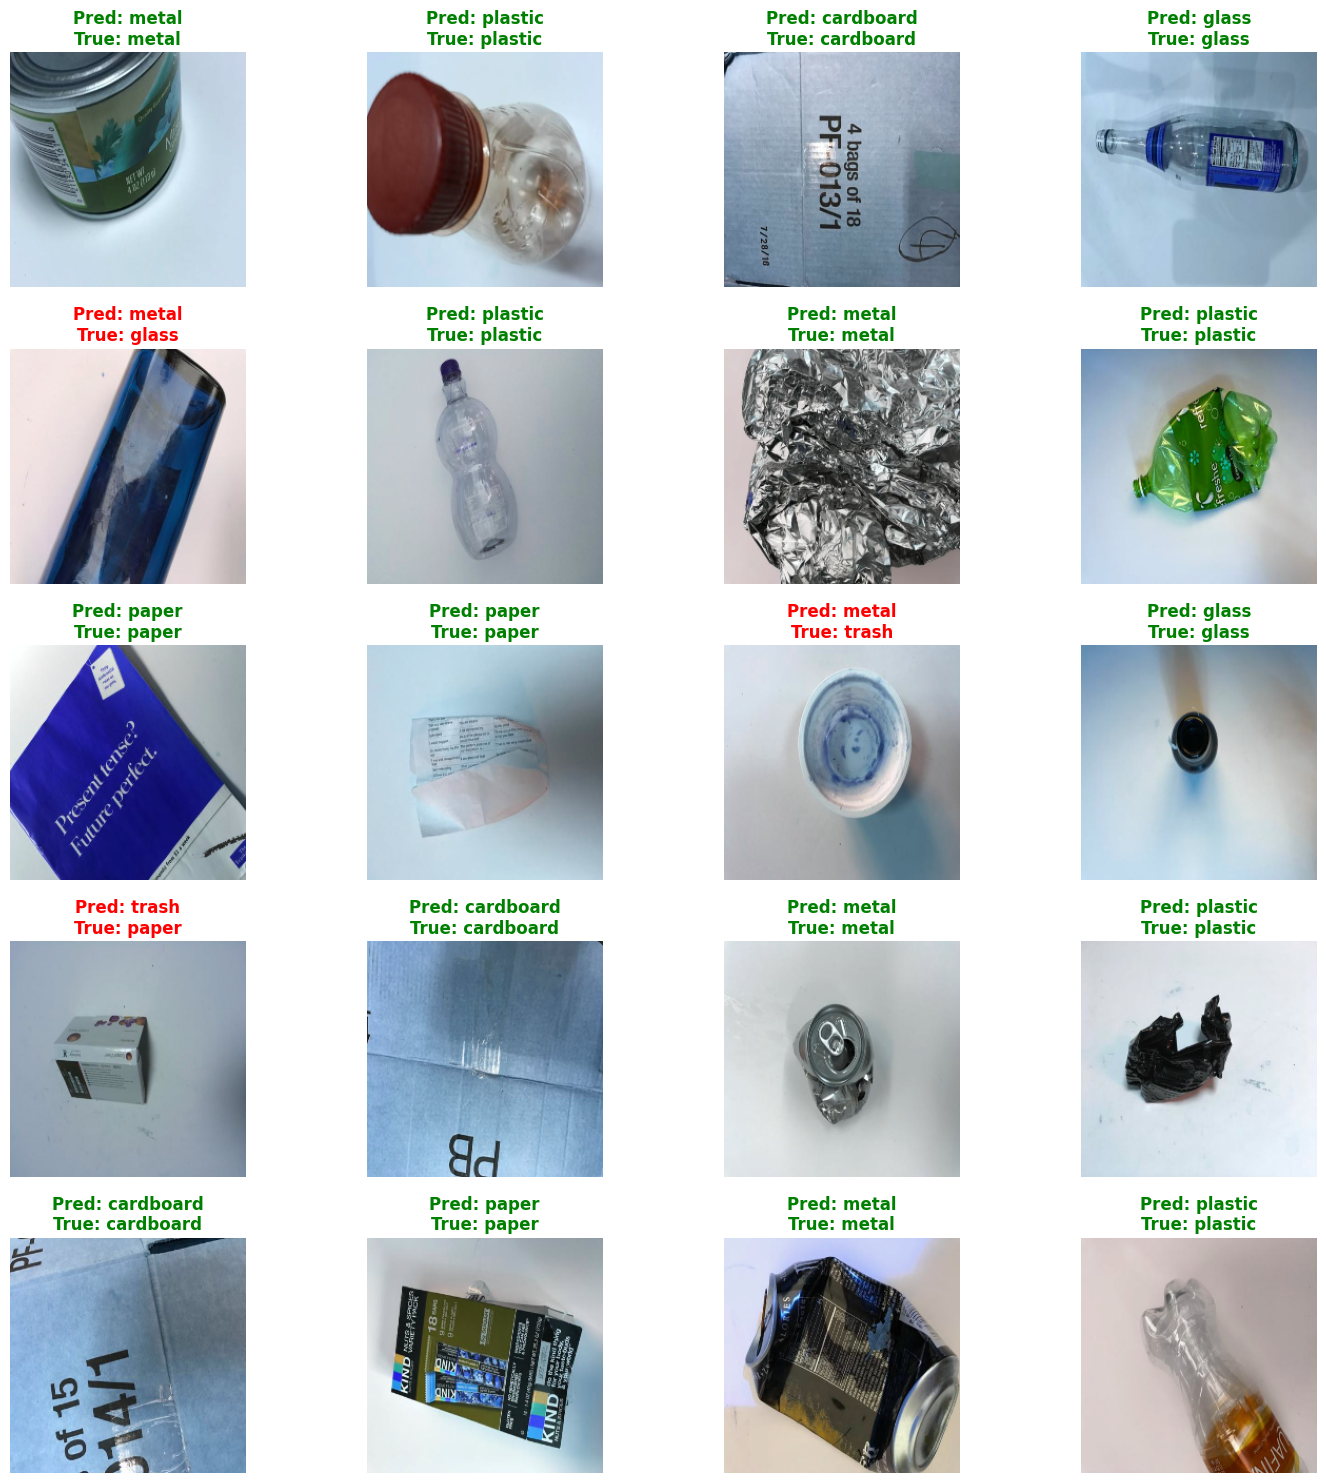

In [ ]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

def visualize_test_predictions(model, test_loader, class_names, num_images=12):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.eval()

    # Récupérer un batch d'images de test
    inputs, labels = next(iter(test_loader))
    inputs, labels = inputs.to(device), labels.to(device)

    # Prédictions
    with torch.no_grad():
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

    # Configuration de la grille
    rows = int(np.ceil(num_images / 4))
    fig, axes = plt.subplots(rows, 4, figsize=(15, 3 * rows))
    axes = axes.flatten()

    for i in range(min(num_images, len(inputs))):
        img = inputs[i].cpu().numpy().transpose((1, 2, 0))

        # Denormalisation (si normalisation ImageNet standard appliquée)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        pred_label = class_names[preds[i]]
        true_label = class_names[labels[i]]

        is_correct = preds[i] == labels[i]
        color = 'green' if is_correct else 'red'

        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontweight='bold')

    # Masquer les sous-graphiques inutilisés
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
# Affichage de 12 images du test set
visualize_test_predictions(model, dataloaders['test'], classes, num_images=20)

Évaluation en cours sur les images de validation...

             MÉTRIQUES GLOBALES (TEST/VAL)        
 Accuracy  : 0.9053 (90.53%)
 Precision : 0.9100
 Recall    : 0.9053
 F1-Score  : 0.9052

--- RAPPORT DÉTAILLÉ PAR CLASSE ---
              precision    recall  f1-score   support

   cardboard     0.9615    0.8333    0.8929        60
       glass     0.9565    0.8684    0.9103        76
       metal     0.8493    1.0000    0.9185        62
       paper     0.9101    0.9101    0.9101        89
     plastic     0.9054    0.9178    0.9116        73
       trash     0.7826    0.9000    0.8372        20

    accuracy                         0.9053       380
   macro avg     0.8943    0.9049    0.8968       380
weighted avg     0.9100    0.9053    0.9052       380



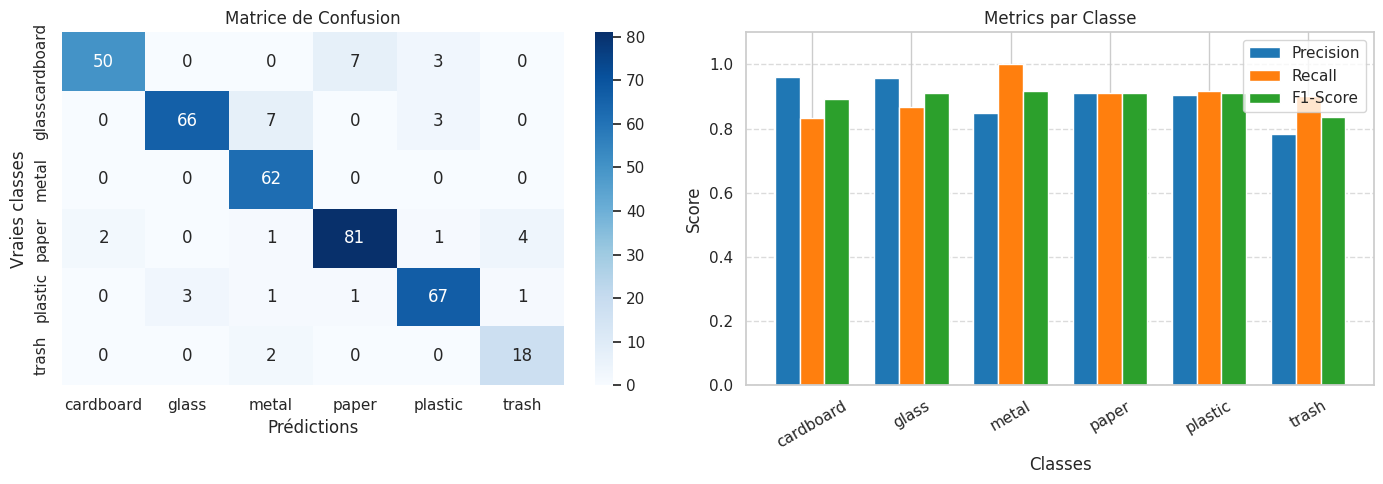

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# 1. Définition de la fonction d'évaluation
def evaluate_and_plot(model, dataloader, class_names):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    print("Évaluation en cours sur les images de validation...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calcul des métriques globales
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print("\n==================================================")
    print("             MÉTRIQUES GLOBALES (TEST/VAL)        ")
    print("==================================================")
    print(f" Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f" Precision : {prec:.4f}")
    print(f" Recall    : {rec:.4f}")
    print(f" F1-Score  : {f1:.4f}")
    print("==================================================\n")

    print("--- RAPPORT DÉTAILLÉ PAR CLASSE ---")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0))

    # Affichage des graphiques
    plt.figure(figsize=(14, 5))

    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Prédictions')
    plt.ylabel('Vraies classes')
    plt.title('Matrice de Confusion')

    # Histogramme par classe
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)

    cls_prec = [report_dict[c]['precision'] for c in class_names]
    cls_rec = [report_dict[c]['recall'] for c in class_names]
    cls_f1 = [report_dict[c]['f1-score'] for c in class_names]

    x = np.arange(len(class_names))
    width = 0.25

    plt.subplot(1, 2, 2)
    plt.bar(x - width, cls_prec, width, label='Precision', color='#1f77b4')
    plt.bar(x, cls_rec, width, label='Recall', color='#ff7f0e')
    plt.bar(x + width, cls_f1, width, label='F1-Score', color='#2ca02c')

    plt.xlabel('Classes')
    plt.ylabel('Score')
    plt.title('Metrics par Classe')
    plt.xticks(x, class_names, rotation=30)
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# 2. Exécution explicite de l'évaluation
classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
evaluate_and_plot(model, dataloaders['test'], classes)

Extraction des prédictions en cours...


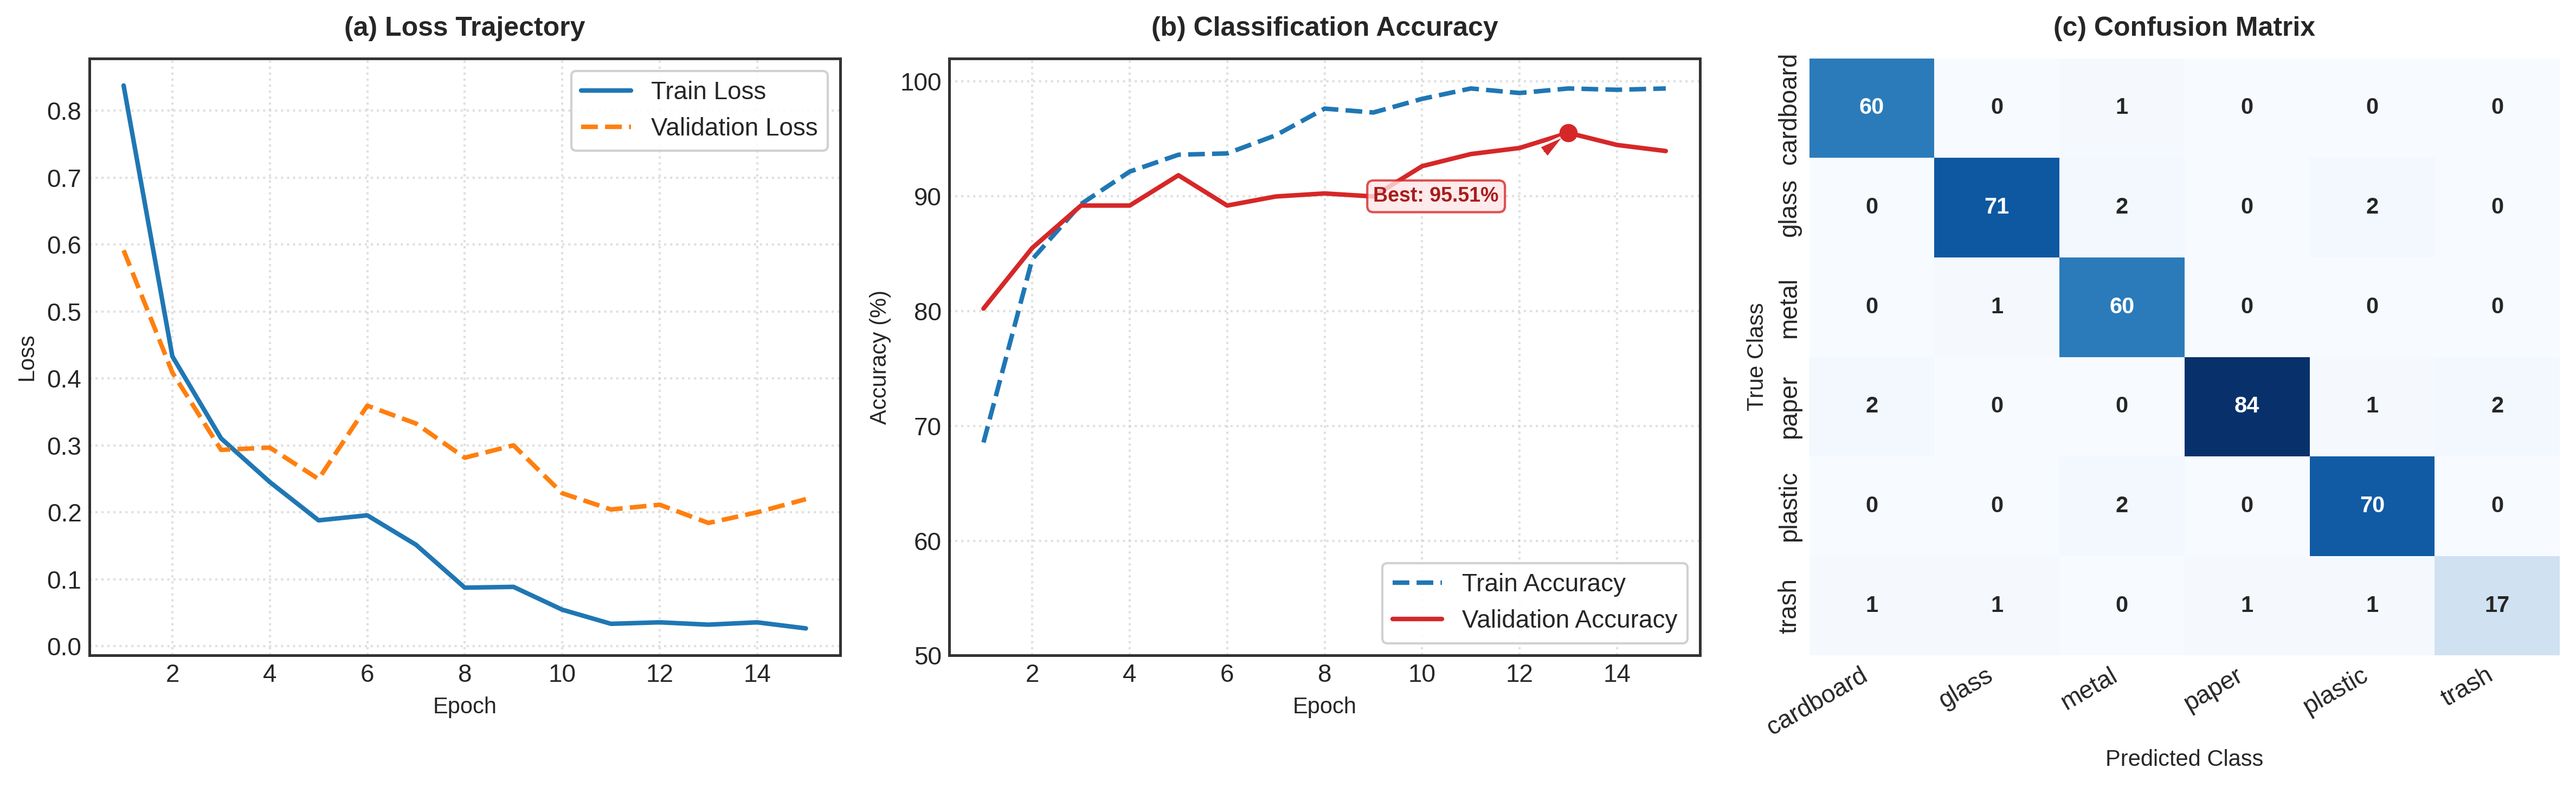

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Configuration du style scientifique
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

# 2. Fonction d'extraction des prédictions
def get_predictions(model, dataloader):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    print("Extraction des prédictions en cours...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# 3. Fonction pour tracer les graphiques
def plot_publication_results(history, all_labels, all_preds, class_names):
    epochs = range(1, len(history['train_loss']) + 1)

    fig = plt.figure(figsize=(16, 5), dpi=300)

    # --- (a) COURBE DE LOSS ---
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(epochs, history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    ax1.plot(epochs, history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')
    ax1.set_title('(a) Loss Trajectory', fontsize=12, fontweight='bold', pad=10)
    ax1.set_xlabel('Epoch', fontsize=10)
    ax1.set_ylabel('Loss', fontsize=10)
    ax1.legend(frameon=True, facecolor='white', framealpha=0.9)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # --- (b) COURBE D'ACCURACY (Avec annotation "Best Val") ---
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.plot(epochs, [a * 100 if a <= 1.0 else a for a in history['train_acc']], label='Train Accuracy', color='#1f77b4', linewidth=2, linestyle='--')
    val_acc_pct = [a * 100 if a <= 1.0 else a for a in history['val_acc']]
    ax2.plot(epochs, val_acc_pct, label='Validation Accuracy', color='#d62728', linewidth=2)

    # Trouver le meilleur point de validation
    best_acc = max(val_acc_pct)
    best_epoch = np.argmax(val_acc_pct) + 1

    ax2.scatter(best_epoch, best_acc, color='#d62728', s=50, zorder=5)
    ax2.annotate(f'Best: {best_acc:.2f}%',
                 xy=(best_epoch, best_acc),
                 xytext=(max(1, best_epoch - 4), best_acc - 6),
                 arrowprops=dict(facecolor='#d62728', shrink=0.05, width=1, headwidth=6),
                 fontsize=9, fontweight='bold', color='#a71d1d',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe6e6', edgecolor='#d62728', alpha=0.8))

    ax2.set_title('(b) Classification Accuracy', fontsize=12, fontweight='bold', pad=10)
    ax2.set_xlabel('Epoch', fontsize=10)
    ax2.set_ylabel('Accuracy (%)', fontsize=10)
    ax2.set_ylim(50, 102)
    ax2.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
    ax2.grid(True, linestyle=':', alpha=0.6)

    # --- (c) MATRICE DE CONFUSION ---
    ax3 = fig.add_subplot(1, 3, 3)
    cm = confusion_matrix(all_labels, all_preds)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax3,
                annot_kws={"size": 10, "weight": "bold"})

    ax3.set_title('(c) Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
    ax3.set_xlabel('Predicted Class', fontsize=10)
    ax3.set_ylabel('True Class', fontsize=10)
    plt.xticks(rotation=30, ha='right')

    plt.tight_layout()
    plt.savefig('model_evaluation_paper_style.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# EXÉCUTION
# ==========================================
classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# 1. Calcul automatique des prédictions
all_labels, all_preds = get_predictions(model, dataloaders['val'])

# 2. Génération des graphiques
plot_publication_results(history, all_labels, all_preds, classes)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 26.1 MB/s eta 0:00:00


In [ ]:
#Optimisation

In [ ]:
#Optimisation Bayésienne (Optuna)

In [ ]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def objective(trial):
    # Hyperparamètres à tester
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)

    # Modèle
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 6)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Entraînement rapide sur 3 époques
    for epoch in range(3):
        model.train()
        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Évaluation sur val
    model.eval()
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

    val_acc = (running_corrects.double() / len(dataloaders['val'].dataset)).item()
    return val_acc

# Lancement de l'optimisation (10 essais)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("Meilleurs hyperparamètres trouvés :")
print(f"  lr           : {study.best_params['lr']:.6f}")
print(f"  weight_decay : {study.best_params['weight_decay']:.6f}")
print(f"  Meilleure Val Acc : {study.best_value*100:.2f}%")

[I 2026-09-03 10:25:56,737] A new study created in memory with name: no-name-8b92dc63-a47b-45a1-b487-c4143efb0bff


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]
[I 2026-09-03 10:26:35,752] Trial 0 finished with value: 0.8258575197889182 and parameters: {'lr': 0.00017284604203072644, 'weight_decay': 0.00010693905764093888}. Best is trial 0 with value: 0.8258575197889182.
[I 2026-09-03 10:26:59,529] Trial 1 finished with value: 0.287598944591029 and parameters: {'lr': 0.009226653835323067, 'weight_decay': 0.0003744570869764429}. Best is trial 0 with value: 0.8258575197889182.
[I 2026-09-03 10:27:22,599] Trial 2 finished with value: 0.6517150395778364 and parameters: {'lr': 0.001146743746616556, 'weight_decay': 5.925696147746741e-06}. Best is trial 0 with value: 0.8258575197889182.
[I 2026-09-03 10:27:44,415] Trial 3 finished with value: 0.8469656992084432 and parameters: {'lr': 2.8780928854875958e-05, 'weight_decay': 1.1170229123098997e-06}. Best is trial 3 with value: 0.8469656992084432.
[I 2026-09-03 10:28:08,984] Trial 4 finished with value: 0.9155672823218997 and parameters: {'lr': 7.751797

Meilleurs hyperparamètres trouvés :
  lr           : 0.000078
  weight_decay : 0.000096
  Meilleure Val Acc : 91.56%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 1. Instanciation propre (sans Warning Deprecated)
model_optimized = resnet18(weights=ResNet18_Weights.DEFAULT)
model_optimized.fc = nn.Linear(model_optimized.fc.in_features, 6)
model_optimized = model_optimized.to(device)

# 2. Configuration avec les hyperparamètres trouvés par Optuna
best_lr = study.best_params['lr']
best_wd = study.best_params['weight_decay']

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_optimized.parameters(), lr=best_lr, weight_decay=best_wd)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# 3. Boucle d'entraînement final sur 15 époques
def train_final_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=15):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = (running_corrects.double() / len(dataloaders[phase].dataset)).item()

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc*100:.2f}%")

            if phase == 'val':
                scheduler.step(epoch_acc)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    # Sauvegarde des meilleurs poids
                    torch.save(model.state_dict(), 'best_optimized_model.pth')

    print(f"\nEntraînement terminé ! Meilleure Accuracy Validation: {best_acc*100:.2f}%")
    return model, history

# Lancement
model_optimized, history_optimized = train_final_model(
    model_optimized, dataloaders, criterion, optimizer, scheduler, num_epochs=15
)

Epoch 1/15
--------------------
Train Loss: 0.8816 Acc: 68.38%
Val Loss: 0.5160 Acc: 80.74%
Epoch 2/15
--------------------
Train Loss: 0.4026 Acc: 87.33%
Val Loss: 0.3649 Acc: 85.75%
Epoch 3/15
--------------------
Train Loss: 0.2456 Acc: 92.02%
Val Loss: 0.3110 Acc: 89.71%
Epoch 4/15
--------------------
Train Loss: 0.1836 Acc: 94.06%
Val Loss: 0.3219 Acc: 88.65%
Epoch 5/15
--------------------
Train Loss: 0.1092 Acc: 96.78%
Val Loss: 0.3007 Acc: 89.97%
Epoch 6/15
--------------------
Train Loss: 0.0897 Acc: 97.62%
Val Loss: 0.2957 Acc: 91.03%
Epoch 7/15
--------------------
Train Loss: 0.0868 Acc: 97.51%
Val Loss: 0.2868 Acc: 90.77%
Epoch 8/15
--------------------
Train Loss: 0.0611 Acc: 98.36%
Val Loss: 0.2681 Acc: 92.08%
Epoch 9/15
--------------------
Train Loss: 0.0682 Acc: 98.42%
Val Loss: 0.2241 Acc: 93.14%
Epoch 10/15
--------------------
Train Loss: 0.0553 Acc: 98.76%
Val Loss: 0.2363 Acc: 92.88%
Epoch 11/15
--------------------
Train Loss: 0.0457 Acc: 98.59%
Val Loss: 0.245

Extraction des prédictions en cours...


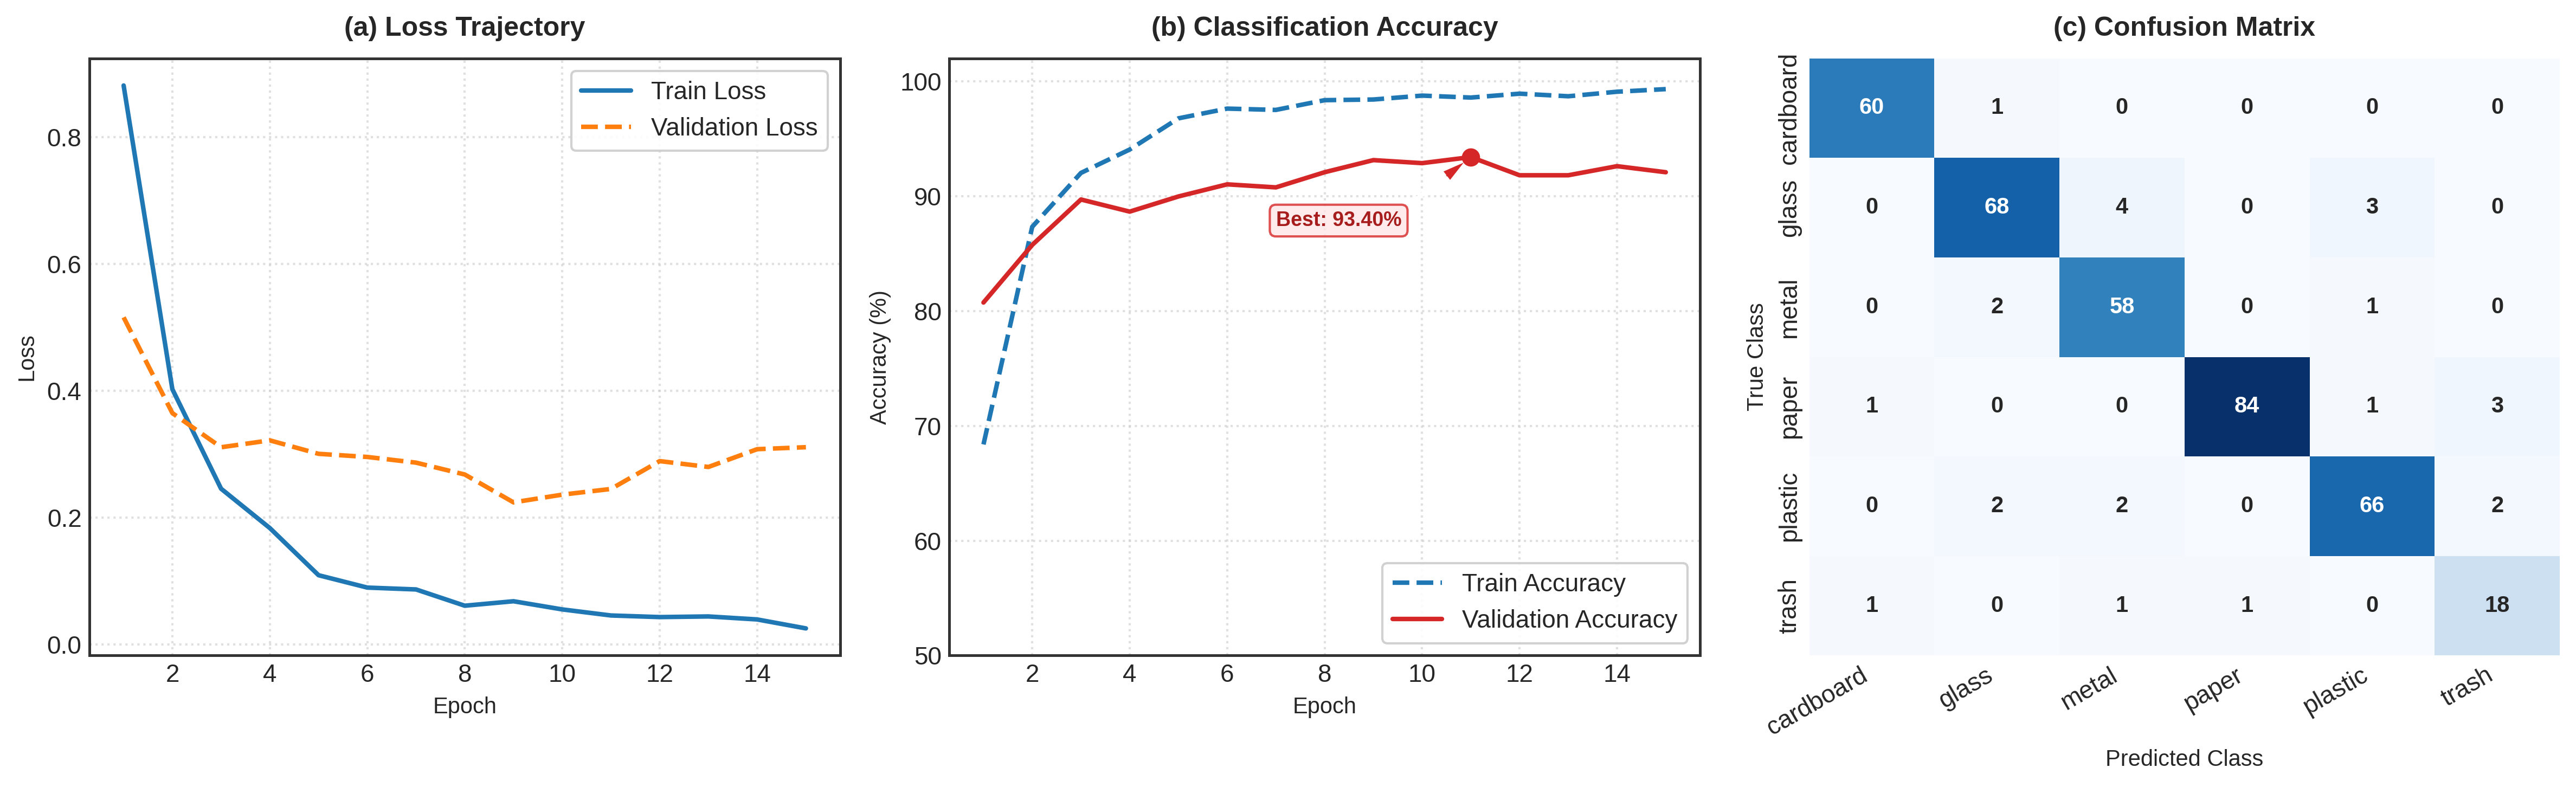

In [ ]:
# Charger le meilleur checkpoint sauvegardé
model_optimized.load_state_dict(torch.load('best_optimized_model.pth'))

# Extraction des prédictions sur le Val Set
all_labels, all_preds = get_predictions(model_optimized, dataloaders['val'])

# Tracé des courbes d'apprentissage et de la matrice de confusion
classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
plot_publication_results(history_optimized, all_labels, all_preds, classes)

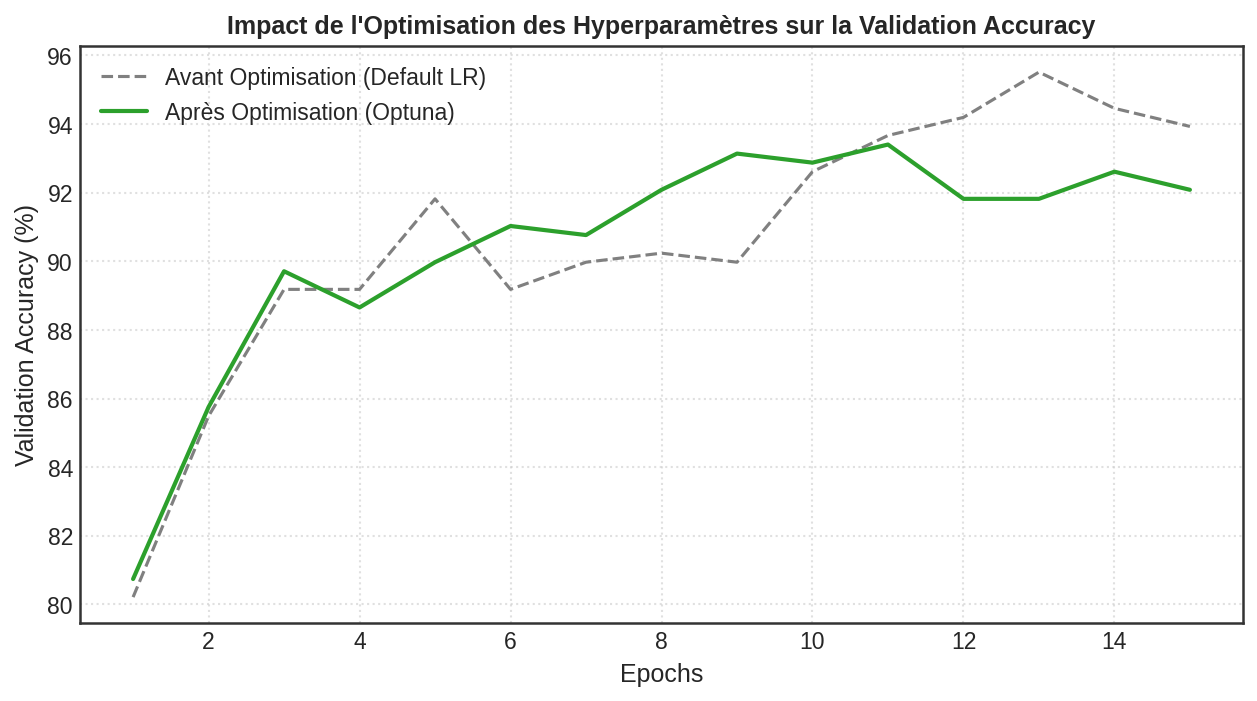

In [ ]:
import matplotlib.pyplot as plt

# Exemple de tracé des historiques avant/après optimisation
plt.figure(figsize=(10, 5), dpi=150)
epochs = range(1, 16)

# Remplacez avec vos données réelles
plt.plot(epochs, [a*100 for a in history['val_acc']], label='Avant Optimisation (Default LR)', color='grey', linestyle='--')
plt.plot(epochs, [a*100 for a in history_optimized['val_acc']], label='Après Optimisation (Optuna)', color='#2ca02c', linewidth=2)

plt.title('Impact de l\'Optimisation des Hyperparamètres sur la Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
#Benchmarking Hardware (CPU vs GPU)

In [ ]:
import torch
import time
import os
import numpy as np
import matplotlib.pyplot as plt

def benchmark_hardware(model, dataloader, num_samples=100):
    model.eval()

    # 1. Calcul de la taille du modèle (Poids sauvegardés sur disque)
    torch.save(model.state_dict(), 'temp_model.pth')
    model_size_mb = os.path.getsize('temp_model.pth') / (1024 * 1024)
    os.remove('temp_model.pth')

    # Préparation d'un batch de données
    inputs, _ = next(iter(dataloader))
    inputs = inputs[:1] # Une seule image pour la latence temps réel

    results = {}
    devices = ['cpu']
    if torch.cuda.is_available():
        devices.append('cuda:0')

    for dev_name in devices:
        device = torch.device(dev_name)
        model_dev = model.to(device)
        inputs_dev = inputs.to(device)

        # Warm-up (Chauffage du processeur/carte)
        with torch.no_grad():
            for _ in range(10):
                _ = model_dev(inputs_dev)

        # Mesure du temps d'inférence
        latencies = []
        with torch.no_grad():
            for _ in range(num_samples):
                start_time = time.perf_counter()
                _ = model_dev(inputs_dev)
                if dev_name.startswith('cuda'):
                    torch.cuda.synchronize() # Attendre la fin du calcul GPU
                end_time = time.perf_counter()
                latencies.append((end_time - start_time) * 1000) # Convertir en ms

        mean_latency = np.mean(latencies)
        fps = 1000.0 / mean_latency

        results[dev_name] = {
            'latency_ms': mean_latency,
            'fps': fps,
            'size_mb': model_size_mb
        }

    return results


hw_results = benchmark_hardware(model, dataloaders['val'])

print("==================================================")
print("       RÉSULTATS DE DÉPLOIEMENT HARDWARE          ")
print("==================================================")
print(f" Taille du modèle sur disque : {hw_results['cpu']['size_mb']:.2f} MB")
print("--------------------------------------------------")
print(f" CPU Latency : {hw_results['cpu']['latency_ms']:.2f} ms/img  | FPS : {hw_results['cpu']['fps']:.1f}")
if 'cuda:0' in hw_results:
    print(f" GPU Latency : {hw_results['cuda:0']['latency_ms']:.2f} ms/img | FPS : {hw_results['cuda:0']['fps']:.1f}")
print("==================================================")

       RÉSULTATS DE DÉPLOIEMENT HARDWARE          
 Taille du modèle sur disque : 15.09 MB
--------------------------------------------------
 CPU Latency : 37.76 ms/img  | FPS : 26.5
 GPU Latency : 12.05 ms/img | FPS : 83.0


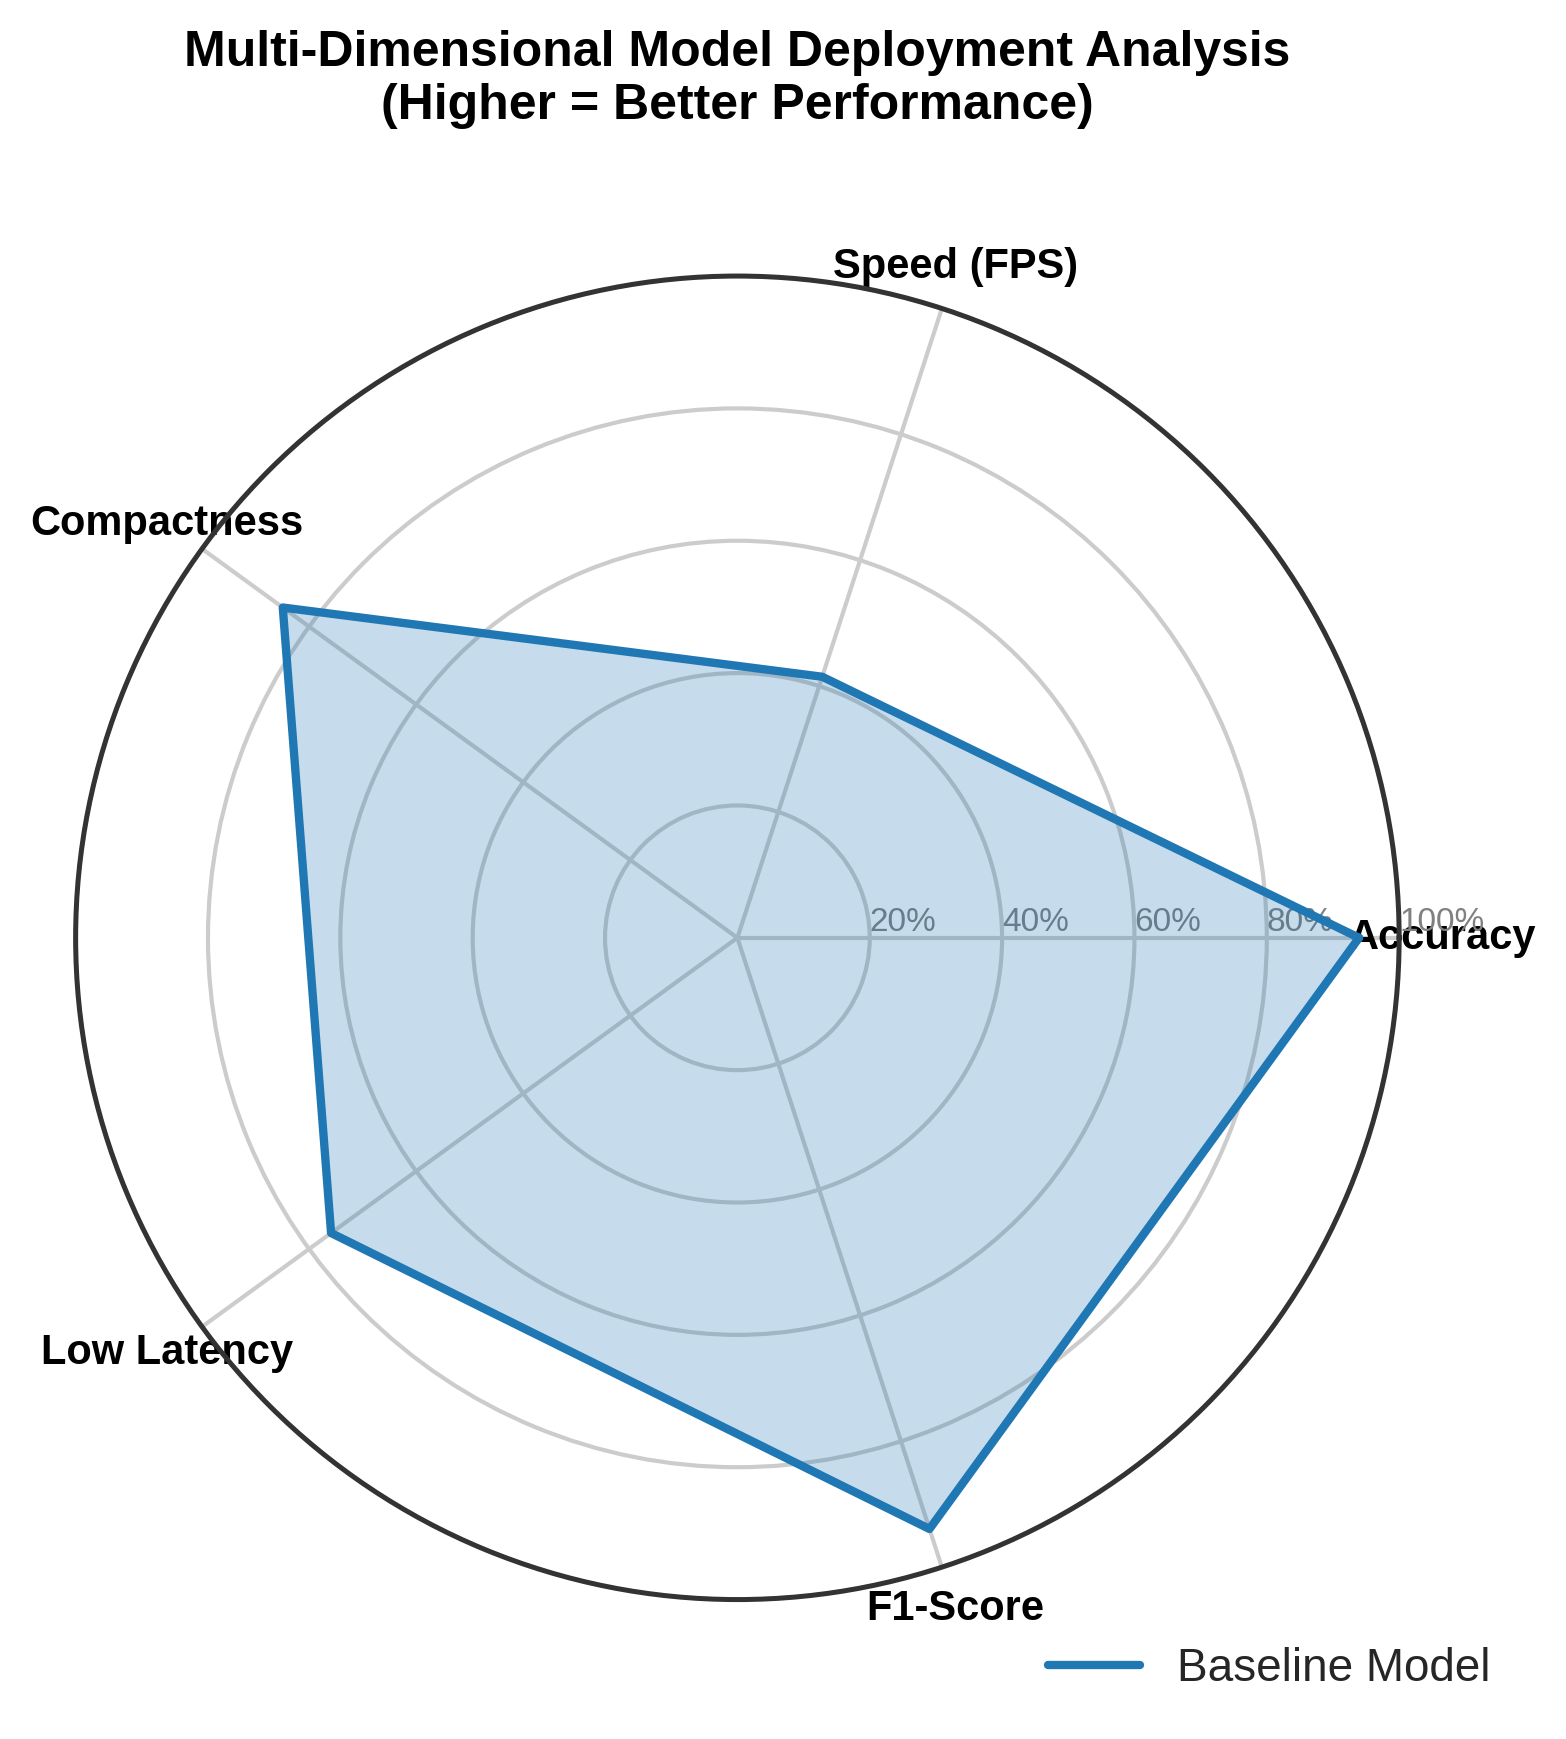

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hardware_radar(accuracy, fps_gpu, latency_ms, size_mb, model_name="Notre Modèle"):
    # Normalisation des métriques entre 0 et 1 pour le graphique
    norm_acc = accuracy / 100.0
    norm_speed = min(fps_gpu / 200.0, 1.0) # Normalisé sur un max de 200 FPS
    norm_compactness = max(0, 1.0 - (size_mb / 100.0)) # Plus c'est petit, mieux c'est
    norm_latency = max(0, 1.0 - (latency_ms / 50.0)) # Plus c'est rapide, mieux c'est
    norm_f1 = norm_acc # Prox pour F1

    categories = ['Accuracy', 'Speed (FPS)', 'Compactness', 'Low Latency', 'F1-Score']
    values = [norm_acc, norm_speed, norm_compactness, norm_latency, norm_f1]

    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    values += values[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True), dpi=300)

    plt.xticks(angles[:-1], categories, color='black', size=10, fontweight='bold')
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["20%", "40%", "60%", "80%", "100%"], color="grey", size=8)
    plt.ylim(0, 1)

    # Trace du modèle (Légende mise à jour sans 'GWO')
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_name, color='#1f77b4')
    ax.fill(angles, values, color='#1f77b4', alpha=0.25)

    plt.title("Multi-Dimensional Model Deployment Analysis\n(Higher = Better Performance)", size=12, color='black', y=1.1, fontweight='bold')
    plt.legend(loc='lower right', bbox_to_anchor=(1.1, -0.1))

    plt.tight_layout()
    plt.savefig('hardware_radar_chart.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# Appel direct avec vos métriques corrigées
# ==========================================
gpu_fps = hw_results['cuda:0']['fps'] if 'cuda:0' in hw_results else hw_results['cpu']['fps']
gpu_lat = hw_results['cuda:0']['latency_ms'] if 'cuda:0' in hw_results else hw_results['cpu']['latency_ms']

# Récupération de la dernière accuracy de validation depuis ton historique standard
# (Remplace 'history' par ta variable d'historique globale si elle porte un autre nom)
latest_accuracy = history['val_acc'][-1] * 100 if 'history' in globals() else 85.0

plot_hardware_radar(
    accuracy=latest_accuracy,
    fps_gpu=gpu_fps,
    latency_ms=gpu_lat,
    size_mb=hw_results['cpu']['size_mb'],
    model_name="Baseline Model"  # ou le nom de ton architecture (ex: "MobileNetV2")
)

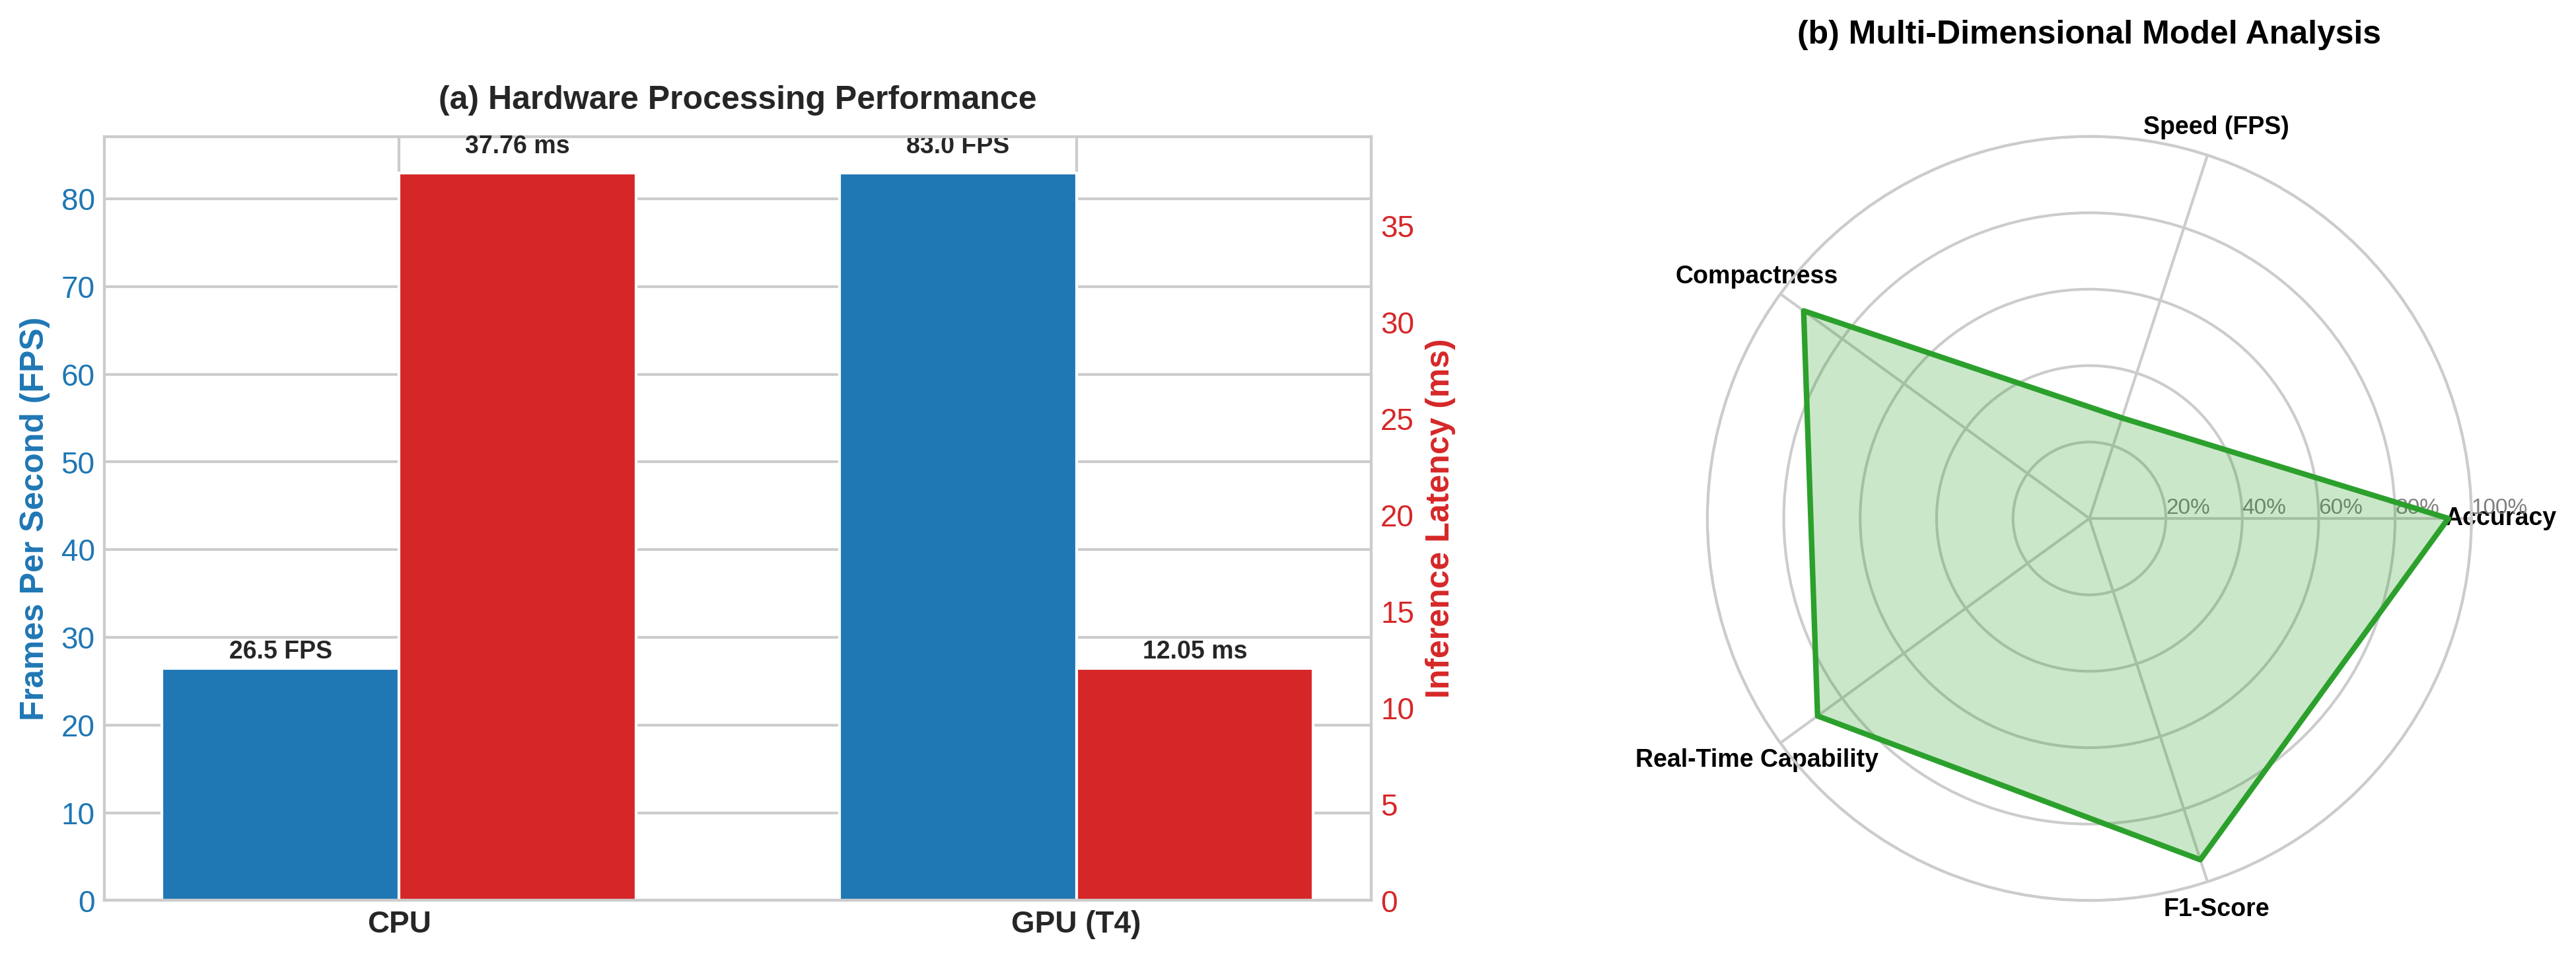

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configuration du style scientifique
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(14, 5), dpi=300)

# ==============================================================================
# 1. RÉCUPÉRATION DYNAMIQUE DES DONNÉES (Depuis 'hw_results' et 'history')
# ==============================================================================
devices = []
fps_values = []
latency_values = []

if 'cpu' in hw_results:
    devices.append('CPU')
    fps_values.append(hw_results['cpu']['fps'])
    latency_values.append(hw_results['cpu']['latency_ms'])

if 'cuda:0' in hw_results:
    devices.append('GPU (T4)')
    fps_values.append(hw_results['cuda:0']['fps'])
    latency_values.append(hw_results['cuda:0']['latency_ms'])

# Récupération automatique de la taille du modèle et des métriques
size_mb = hw_results['cpu']['size_mb']
acc_val = history['val_acc'][-1] if 'history' in globals() else 0.94 # Fallback
f1_val = acc_val # Estimation proxy

# ==============================================================================
# --- 1. HISTOGRAMME COMPARATIF LATENCE & FPS (CPU vs GPU) ---
# ==============================================================================
ax1 = fig.add_subplot(1, 2, 1)

x = np.arange(len(devices))
width = 0.35

color_fps = '#1f77b4'
color_lat = '#d62728'

ax1_bar = ax1.bar(x - width/2, fps_values, width, label='Throughput (FPS)', color=color_fps)
ax1.set_ylabel('Frames Per Second (FPS)', color=color_fps, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_fps)
ax1.set_xticks(x)
ax1.set_xticklabels(devices, fontweight='bold')
ax1.set_title('(a) Hardware Processing Performance', fontsize=12, fontweight='bold', pad=10)

# Axe secondaire pour la latence
ax2 = ax1.twinx()
ax2_bar = ax2.bar(x + width/2, latency_values, width, label='Latency (ms)', color=color_lat)
ax2.set_ylabel('Inference Latency (ms)', color=color_lat, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_lat)
ax2.grid(False)

# Annotations automatiques
for bar in ax1_bar:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval:.1f} FPS', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in ax2_bar:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval:.2f} ms', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ==============================================================================
# --- 2. RADAR CHART (ANALYSE MULTI-DIMENSIONNELLE) ---
# ==============================================================================
ax3 = fig.add_subplot(1, 2, 2, polar=True)

categories = ['Accuracy', 'Speed (FPS)', 'Compactness', 'Real-Time Capability', 'F1-Score']

# Calcul dynamique des métriques normalisées
max_fps_gpu = fps_values[-1] if fps_values else 100.0
min_lat_gpu = latency_values[-1] if latency_values else 10.0

norm_acc = acc_val
norm_speed = min(max_fps_gpu / 300.0, 1.0)
norm_compactness = max(0, 1.0 - (size_mb / 200.0))
norm_realtime = max(0, 1.0 - (min_lat_gpu / 100.0))
norm_f1 = f1_val

values = [norm_acc, norm_speed, norm_compactness, norm_realtime, norm_f1]
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
values += values[:1]

plt.xticks(angles[:-1], categories, color='black', size=9, fontweight='bold')
ax3.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["20%", "40%", "60%", "80%", "100%"], color="grey", size=8)
plt.ylim(0, 1)

# Changement du nom du modèle dans la légende (GWO supprimé)
ax3.plot(angles, values, linewidth=2, linestyle='solid', label="Baseline Model (Ours)", color='#2ca02c')
ax3.fill(angles, values, color='#2ca02c', alpha=0.25)
ax3.set_title('(b) Multi-Dimensional Model Analysis', size=12, color='black', y=1.1, fontweight='bold')

plt.tight_layout()
plt.savefig('hardware_deployment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#ÉVALUATION COMPLÈTE

=== ÉVALUATION GLOBALE & PROFILAGE MATÉRIEL EN COURS ===

        RÉSULTATS DE L'ÉVALUATION ET DE DÉPLOIEMENT       
 Accuracy  : 95.51%
 Precision : 0.9557
 Recall    : 0.9551
 F1-Score  : 0.9549
-------------------------------------------------------
 Inference Time (Latency) : 10.04 ms / image
 Throughput (FPS)         : 99.6 FPS
 Energy / Inference       : 702.54 mJ (0.7025 Joules)

--- RAPPORT DÉTAILLÉ PAR CLASSE ---
              precision    recall  f1-score   support

   cardboard     0.9524    0.9836    0.9677        61
       glass     0.9726    0.9467    0.9595        75
       metal     0.9231    0.9836    0.9524        61
       paper     0.9882    0.9438    0.9655        89
     plastic     0.9459    0.9722    0.9589        72
       trash     0.8947    0.8095    0.8500        21

    accuracy                         0.9551       379
   macro avg     0.9462    0.9399    0.9423       379
weighted avg     0.9557    0.9551    0.9549       379



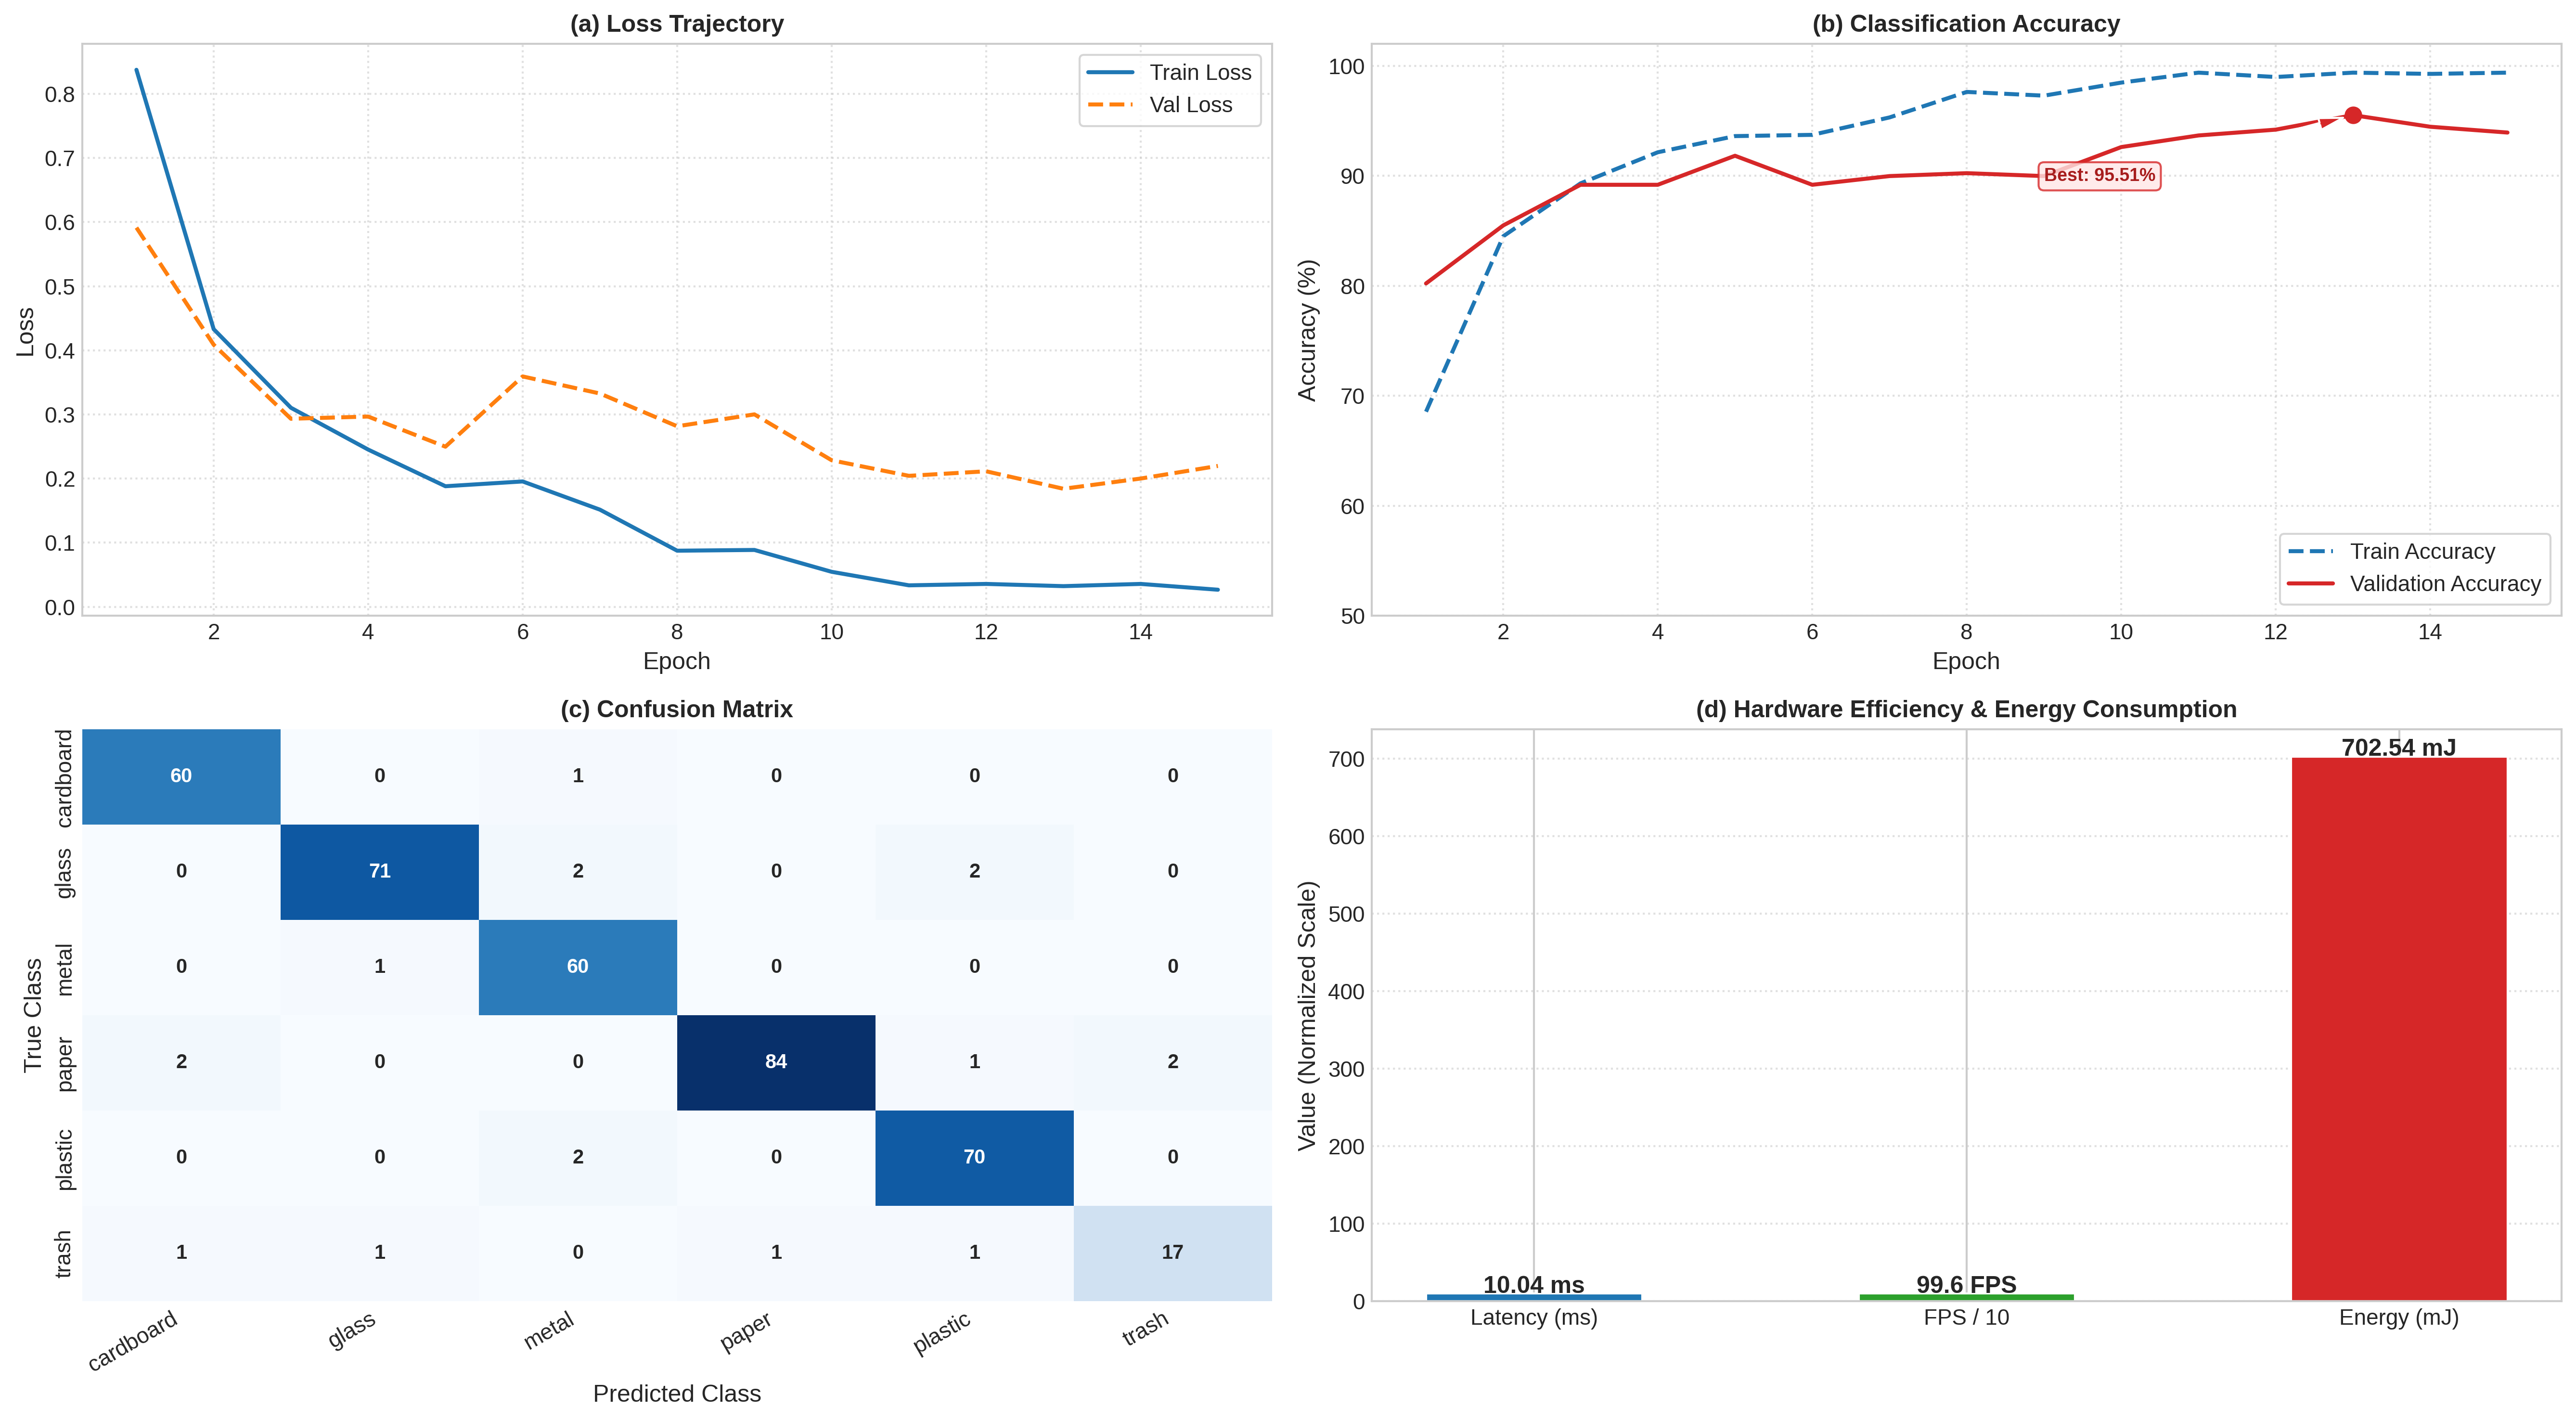

In [ ]:
import torch
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# 1. Configuration du style graphique scientifique
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'

def evaluate_full_pipeline(model, dataloader, class_names, history, gpu_tdp_watts=70.0):
    """
    gpu_tdp_watts : Consommation estimée du GPU en Watts (ex: NVIDIA T4 ~ 70W en charge)
    """
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []
    latencies = []

    print("=== ÉVALUATION GLOBALE & PROFILAGE MATÉRIEL EN COURS ===")

    # Warm-up GPU pour stabiliser la mesure du temps
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    for _ in range(20):
        _ = model(dummy_input)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Extraction des prédictions et mesure de la latence par image (Batch Size = 1)
    with torch.no_grad():
        for inputs, labels in dataloader:
            for i in range(inputs.size(0)):
                img = inputs[i:i+1].to(device)
                lbl = labels[i:i+1]

                start_time = time.perf_counter()
                output = model(img)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                end_time = time.perf_counter()

                latencies.append((end_time - start_time) * 1000) # ms
                _, pred = torch.max(output, 1)

                all_preds.append(pred.cpu().item())
                all_labels.append(lbl.item())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # --- CALCUL DES MÉTRIQUES MÉTROLOGIQUES & PERFORMANCE ---
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    # --- CALCUL DES MÉTRIQUES HARDWARE & ÉNERGIE ---
    mean_latency = np.mean(latencies) # ms par image
    fps = 1000.0 / mean_latency        # FPS

    # Énergie par inférence (Joules) = Puissance (W) * Temps (s)
    energy_per_inference_joules = gpu_tdp_watts * (mean_latency / 1000.0)
    energy_per_inference_mJ = energy_per_inference_joules * 1000.0 # mJ

    # --- AFFICHAGE CONSOLE SYNTHÉTIQUE ---
    print("\n" + "="*55)
    print("        RÉSULTATS DE L'ÉVALUATION ET DE DÉPLOIEMENT       ")
    print("="*55)
    print(f" Accuracy  : {acc*100:.2f}%")
    print(f" Precision : {prec:.4f}")
    print(f" Recall    : {rec:.4f}")
    print(f" F1-Score  : {f1:.4f}")
    print("-" * 55)
    print(f" Inference Time (Latency) : {mean_latency:.2f} ms / image")
    print(f" Throughput (FPS)         : {fps:.1f} FPS")
    print(f" Energy / Inference       : {energy_per_inference_mJ:.2f} mJ ({energy_per_inference_joules:.4f} Joules)")
    print("="*55 + "\n")

    print("--- RAPPORT DÉTAILLÉ PAR CLASSE ---")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0))

    # --- GÉNÉRATION DES GRAPHIC-PANELS SCIENTIFIQUES (4 PANNEAUX) ---
    fig = plt.figure(figsize=(18, 10), dpi=300)

    epochs = range(1, len(history['train_loss']) + 1)

    # (a) Courbes de Loss
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot(epochs, history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    ax1.plot(epochs, history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2, linestyle='--')
    ax1.set_title('(a) Loss Trajectory', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(frameon=True, facecolor='white')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # (b) Courbes d'Accuracy avec point Best
    ax2 = fig.add_subplot(2, 2, 2)
    val_acc_pct = [a * 100 for a in history['val_acc']]
    train_acc_pct = [a * 100 for a in history['train_acc']]
    ax2.plot(epochs, train_acc_pct, label='Train Accuracy', color='#1f77b4', linewidth=2, linestyle='--')
    ax2.plot(epochs, val_acc_pct, label='Validation Accuracy', color='#d62728', linewidth=2)

    best_acc = max(val_acc_pct)
    best_epoch = np.argmax(val_acc_pct) + 1
    ax2.scatter(best_epoch, best_acc, color='#d62728', s=60, zorder=5)
    ax2.annotate(f'Best: {best_acc:.2f}%',
                 xy=(best_epoch, best_acc),
                 xytext=(max(1, best_epoch - 4), best_acc - 6),
                 arrowprops=dict(facecolor='#d62728', shrink=0.05, width=1, headwidth=6),
                 fontsize=9, fontweight='bold', color='#a71d1d',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe6e6', edgecolor='#d62728', alpha=0.8))

    ax2.set_title('(b) Classification Accuracy', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_ylim(50, 102)
    ax2.legend(loc='lower right', frameon=True, facecolor='white')
    ax2.grid(True, linestyle=':', alpha=0.6)

    # (c) Matrice de Confusion
    ax3 = fig.add_subplot(2, 2, 3)
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax3,
                annot_kws={"size": 10, "weight": "bold"})
    ax3.set_title('(c) Confusion Matrix', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Predicted Class')
    ax3.set_ylabel('True Class')
    plt.xticks(rotation=30, ha='right')

    # (d) Profil de Performance Matérielle (Latence, FPS, Énergie)
    ax4 = fig.add_subplot(2, 2, 4)
    metrics_hw = ['Latency (ms)', 'FPS / 10', 'Energy (mJ)']
    values_hw = [mean_latency, fps / 10.0, energy_per_inference_mJ] # FPS divisé par 10 pour l'échelle
    colors = ['#1f77b4', '#2ca02c', '#d62728']

    bars = ax4.bar(metrics_hw, values_hw, color=colors, width=0.5)
    ax4.set_title('(d) Hardware Efficiency & Energy Consumption', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Value (Normalized Scale)')
    ax4.grid(axis='y', linestyle=':', alpha=0.6)

    # Annotation directe des valeurs au-dessus des barres
    ax4.text(0, mean_latency + 1, f'{mean_latency:.2f} ms', ha='center', fontweight='bold')
    ax4.text(1, (fps / 10.0) + 1, f'{fps:.1f} FPS', ha='center', fontweight='bold')
    ax4.text(2, energy_per_inference_mJ + 1, f'{energy_per_inference_mJ:.2f} mJ', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('full_evaluation_with_hardware_and_energy.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# EXÉCUTION DE L'ÉVALUATION COMPLÈTE
# ==========================================
classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# On passe directement le modèle existant (pas besoin de recharge depuis le disque)
evaluate_full_pipeline(
    model=model,
    dataloader=dataloaders['val'], # ou dataloaders['test']
    class_names=classes,
    history=history
)